# V5W_05 — Replica dei fenotipi C0/C1 (5 parole)

Adattato da **EEG_16** / **EEG_16b**. I 41 soggetti 5words sono **nuovi** → questa è una **replica indipendente**: i due fenotipi (fronto-motor C0 / fronto-occipital C1) riemergono su una coorte diversa?

Pipeline: feature per-soggetto dai grafi (media `adj` e `H@Hᵀ` → triangolo sup.) → PCA(20) + KMeans(k=2) → silhouette + ARI grafo-vs-ipergrafo + mappa differenza C1−C0 con hub. NB: non si può fare ARI fra coorti (soggetti diversi); la replica si valuta su struttura (silhouette), consistenza (ARI interno) e **anatomia degli hub**.

**Env: `daniele_311`**.

## §1 — Config + montage

In [21]:
import json, logging, re
from collections import defaultdict
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt, torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('v5w05')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
CKPT_DIR = project_root / 'models' / 'v5w05'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

N_CHAN = 61
METRIC = 'abs_pcc'
RANDOM_SEED = 42
triu_idx = np.triu_indices(N_CHAN, k=1)
HG_ROOT = project_root / 'data' / '5words_subjects' / 'graphs' / f'hypergraphs_pruned_{METRIC}'
assert HG_ROOT.exists(), f'Grafi non trovati: {HG_ROOT} — esegui prima V5W_02'

# Montage per topomap (stesso di EEG_40)
import mne
ELOC = project_root / 'src' / 'io' / 'ebneuro.locs'
_RENAME = {'T3':'T7','T4':'T8','T5':'P7','T6':'P8'}; _BAD = {'A1','A2'}
_mont = mne.channels.read_custom_montage(str(ELOC), coord_frame='head')
_pos = _mont.get_positions()['ch_pos']
CHAN_NAMES = [_RENAME.get(c, c) for c in _mont.ch_names if c not in _BAD][:N_CHAN]
CH_POS = {_RENAME.get(c, c): _pos[c] for c in _mont.ch_names if c not in _BAD}
def make_topo_info(ch=CHAN_NAMES):
    info = mne.create_info(list(ch), sfreq=256, ch_types='eeg')
    info.set_montage(mne.channels.make_dig_montage(ch_pos={c: CH_POS[c] for c in ch}, coord_frame='head'), on_missing='warn')
    return info
log.info(f'HG_ROOT: {HG_ROOT}  canali: {len(CHAN_NAMES)}')


10:13:39 INFO     HG_ROOT: /home/daniele_u/miralis-hypergraph-imagined-speech/data/5words_subjects/graphs/hypergraphs_pruned_abs_pcc  canali: 61


## §2 — Feature per-soggetto dai grafi

In [22]:
# Feature per-soggetto: media di adj (grafo) e H@H.T (ipergrafo) -> triangolo sup.
_PAT = re.compile(r'^P(\d+)_S(\d+)$')
subj_trials = defaultdict(list)
for p in sorted(HG_ROOT.rglob('trial_*.pt')):
    m = _PAT.match(p.parent.name)
    if m: subj_trials[int(m.group(1))].append(p)

CACHE = CKPT_DIR / f'feat_{METRIC}.npz'
if CACHE.exists():
    z = np.load(CACHE, allow_pickle=True)
    FEAT_G, FEAT_H, SUBJ = z['feat_g'], z['feat_h'], z['subj'].tolist()
    log.info(f'Cache: G{FEAT_G.shape} H{FEAT_H.shape} ({len(SUBJ)} soggetti)')
else:
    SUBJ, feat_g, feat_h = [], [], []
    for sid in tqdm(sorted(subj_trials), desc='soggetti'):
        adjs, hhts = [], []
        for p in subj_trials[sid]:
            d = torch.load(p, weights_only=False)
            adj = d['adj'].float().numpy()
            if adj.shape != (N_CHAN, N_CHAN): continue
            H = d['H'].float().numpy()
            adjs.append(adj); hhts.append(H @ H.T)
        if not adjs: continue
        SUBJ.append(sid)
        feat_g.append(np.mean(adjs, axis=0)[triu_idx])
        feat_h.append(np.mean(hhts, axis=0)[triu_idx])
    FEAT_G, FEAT_H = np.array(feat_g), np.array(feat_h)
    np.savez(CACHE, feat_g=FEAT_G, feat_h=FEAT_H, subj=np.array(SUBJ))
    log.info(f'Salvato cache: G{FEAT_G.shape} H{FEAT_H.shape} ({len(SUBJ)} soggetti)')


10:13:40 INFO     Cache: G(41, 1830) H(41, 1830) (41 soggetti)


## §2b — PCA scatter soggetti (outlier check)

Proiettiamo le feature (grafo e ipergrafo, concatenate) sulle prime 2 PC. Ogni punto è un soggetto: se qualcuno è molto isolato dagli altri, potrebbe essere un outlier da escludere.

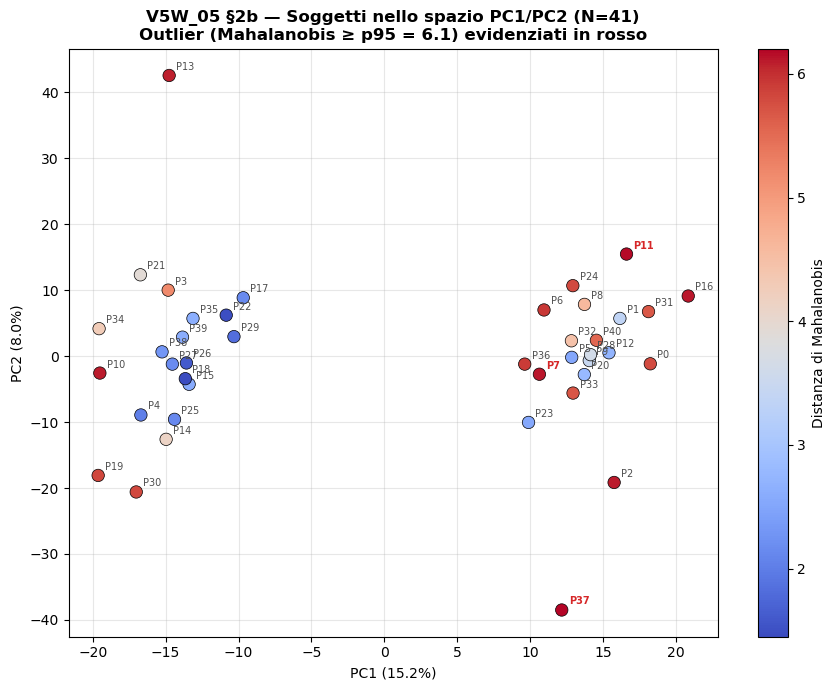


Possibili outlier (Mahal ≥ 6.12, p95):
  P 37  Mahalanobis=6.20  PC1=+12.17  PC2=-38.50
  P 11  Mahalanobis=6.18  PC1=+16.62  PC2=+15.48
  P  7  Mahalanobis=6.12  PC1=+10.64  PC2=-2.74


In [23]:
# §2b — PCA(2) scatter per individuare outlier tra i soggetti
from scipy.spatial.distance import mahalanobis

# Concateno feature grafo + ipergrafo per visione complessiva
FEAT_ALL = np.hstack([FEAT_G, FEAT_H])
X_sc = StandardScaler().fit_transform(FEAT_G)        # era FEAT_ALL
Z_full = PCA(n_components=min(20, FEAT_G.shape[0]-1), random_state=RANDOM_SEED).fit_transform(X_sc)

# Distanza di Mahalanobis dal centroide per quantificare gli outlier
mu = Z_full.mean(axis=0)
cov = np.cov(Z_full, rowvar=False)
cov_inv = np.linalg.inv(cov)
mah = np.array([mahalanobis(z, mu, cov_inv) for z in Z_full])
THR = np.percentile(mah, 95)   # soglia 95-esimo percentile

fig, ax = plt.subplots(figsize=(9, 7))
Z2 = Z_full[:, :2]
pca2_var = PCA(n_components=2, random_state=RANDOM_SEED).fit(X_sc)
sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=mah, cmap='coolwarm',
                edgecolors='k', s=80, linewidths=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label='Distanza di Mahalanobis')

# Annota tutti i soggetti (ID); evidenzia outlier in rosso
for i, sid in enumerate(SUBJ):
    color = '#d62728' if mah[i] >= THR else '0.3'
    weight = 'bold' if mah[i] >= THR else 'normal'
    ax.annotate(f'P{sid}', (Z2[i, 0], Z2[i, 1]),
                fontsize=7, fontweight=weight, color=color,
                textcoords='offset points', xytext=(5, 4))

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'V5W_05 §2b — Soggetti nello spazio PC1/PC2 (N={len(SUBJ)})\n'
             f'Outlier (Mahalanobis ≥ p95 = {THR:.1f}) evidenziati in rosso',
             fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'v5w05_pca_outlier.png', dpi=160, bbox_inches='tight')
plt.show()

# Report outlier
outlier_idx = np.where(mah >= THR)[0]
if len(outlier_idx):
    print(f'\nPossibili outlier (Mahal ≥ {THR:.2f}, p95):')
    for i in np.argsort(-mah[outlier_idx]):
        print(f'  P{SUBJ[outlier_idx[i]]:>3d}  Mahalanobis={mah[outlier_idx[i]]:.2f}'
              f'  PC1={Z2[outlier_idx[i],0]:+.2f}  PC2={Z2[outlier_idx[i],1]:+.2f}')
else:
    print('Nessun outlier evidente (tutti entro il p95).')


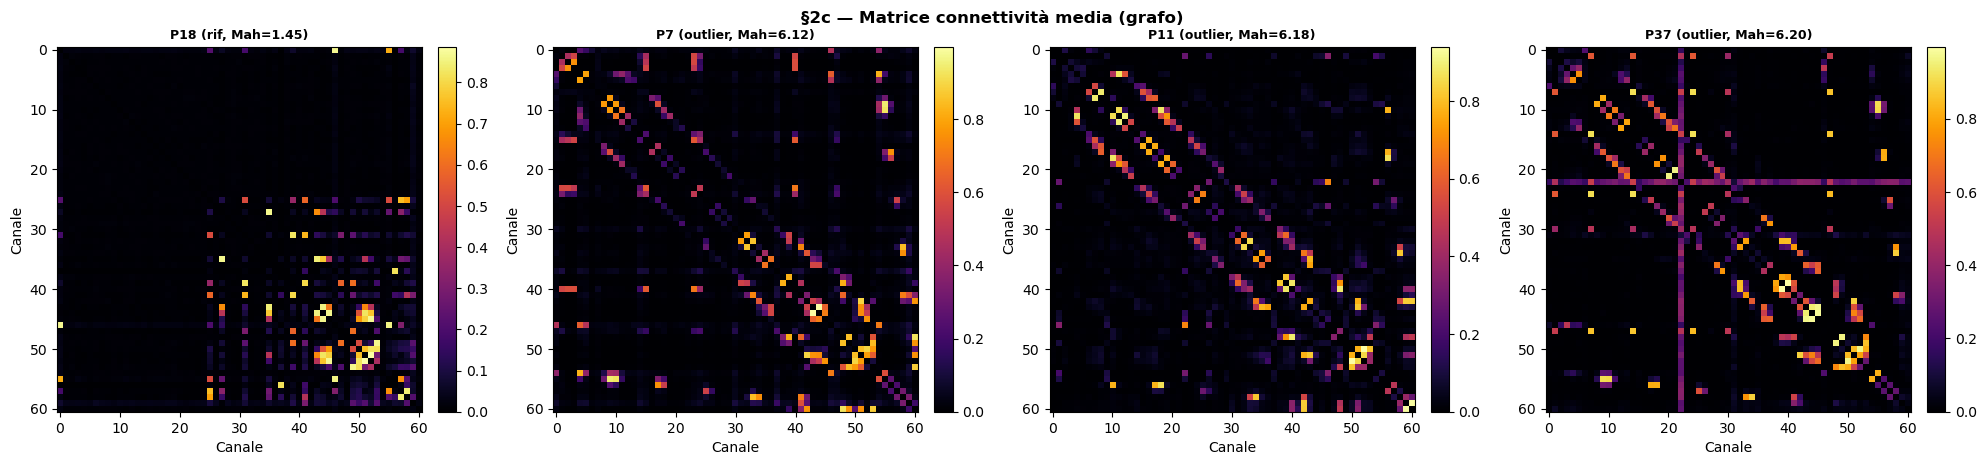

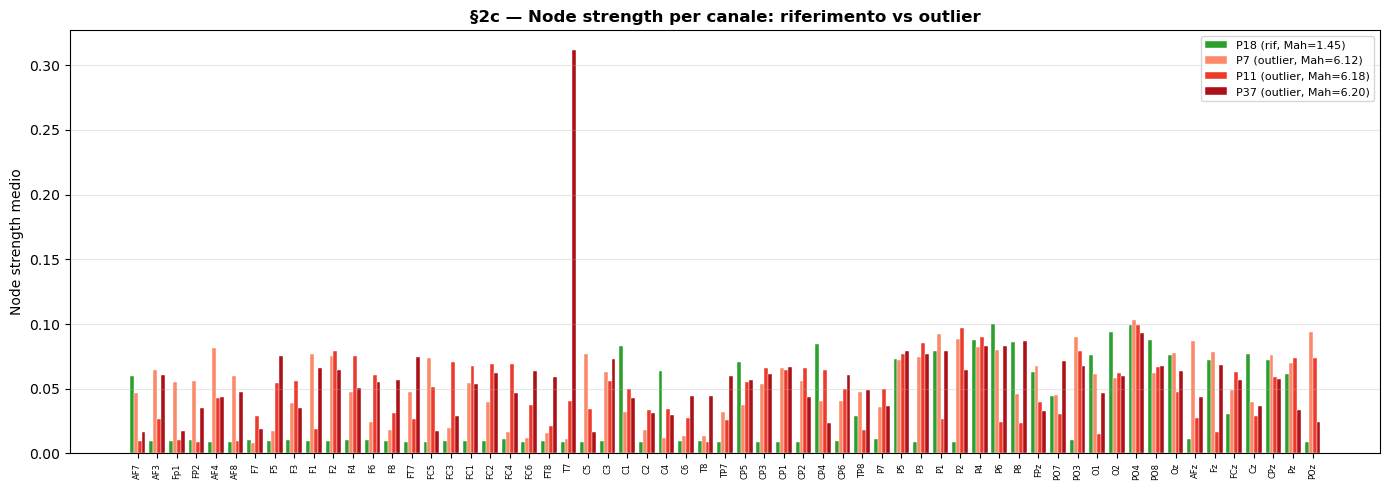

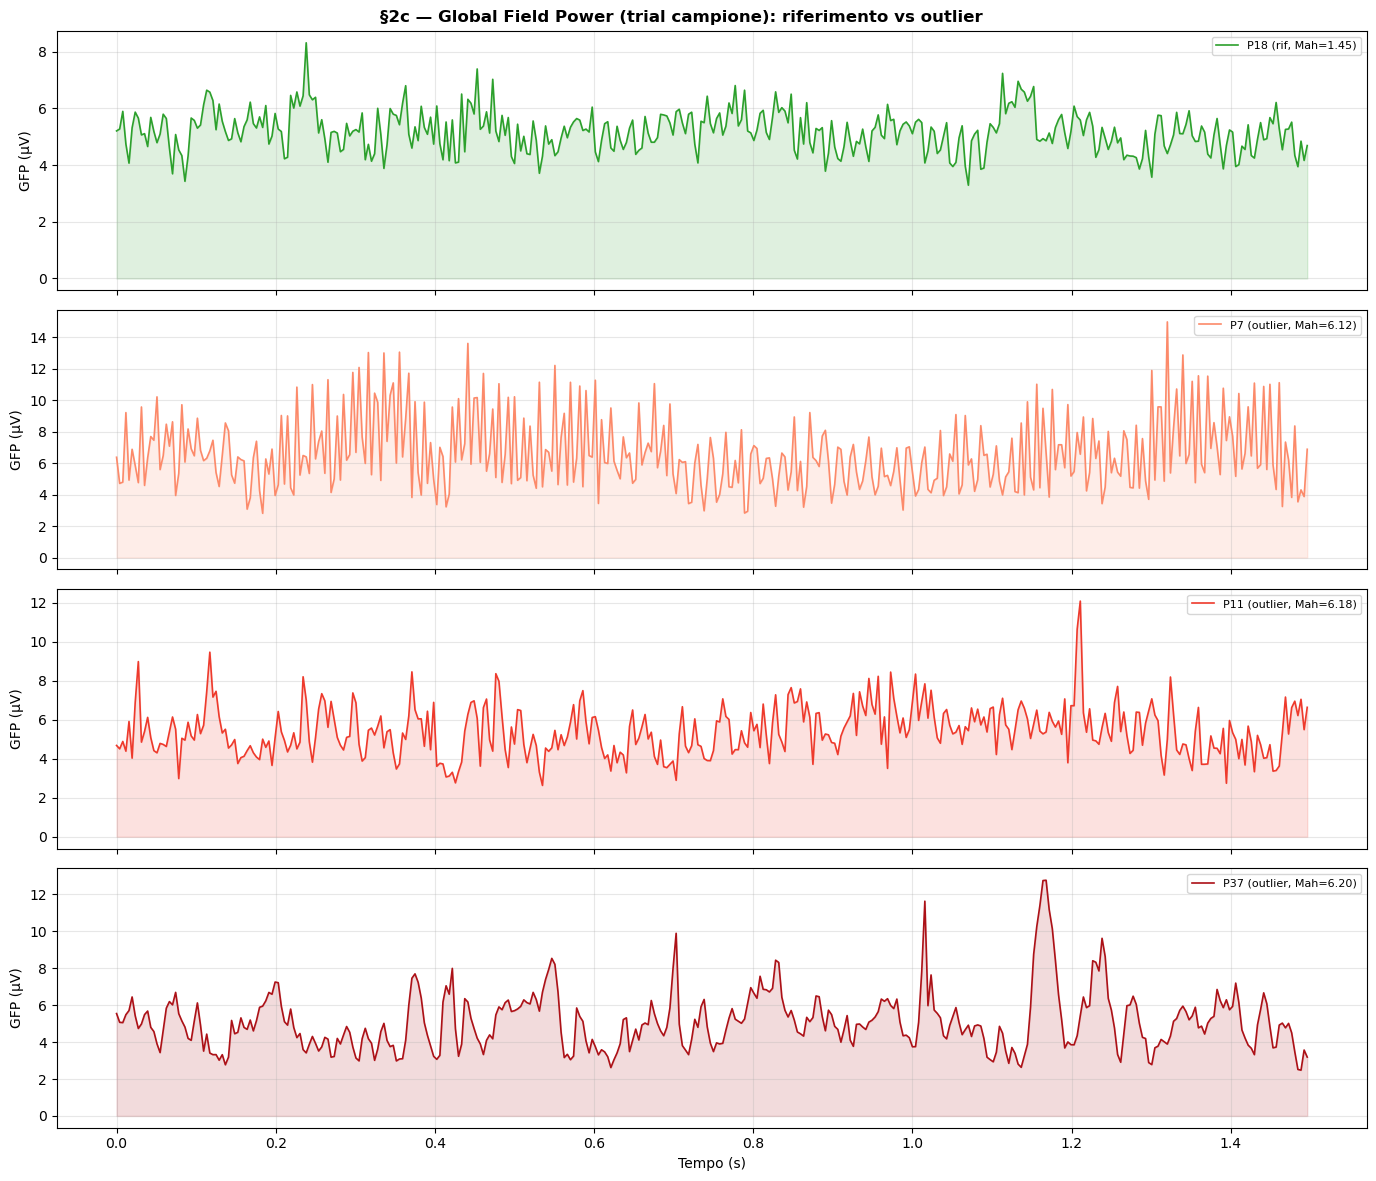

  Riferimento: P18  (Mahalanobis = 1.45)
  Outlier (3):
    P7  Mahalanobis = 6.12
    P11  Mahalanobis = 6.18
    P37  Mahalanobis = 6.20
------------------------------------------------------------
  Controllare:
  • Matrice adj anomala (valori molto alti/bassi)?
  • Node strength uniforme vs picchi singolari?
  • GFP con artefatti (spike, ampiezza >>)?


In [24]:
# §2c — Confronto segnale riferimento vs outlier
# Soggetto riferimento = quello con Mahalanobis più bassa
ref_idx = int(np.argmin(mah))
ref_sid = SUBJ[ref_idx]

# Outlier = quelli sopra la soglia p95 (già calcolata in §2b)
out_idx = np.where(mah >= THR)[0]
out_sids = [SUBJ[i] for i in out_idx]

SUBJ_ROOT = project_root / 'data' / '5words_subjects'
compare_sids = [ref_sid] + out_sids
compare_labels = [f'P{ref_sid} (rif, Mah={mah[ref_idx]:.2f})'] + \
                 [f'P{s} (outlier, Mah={mah[SUBJ.index(s)]:.2f})' for s in out_sids]

# --- colori ---
colors = ['#2ca02c'] + plt.cm.Reds(np.linspace(0.4, 0.85, len(out_sids))).tolist()

# =====================  1) Matrici di connettività media  =====================
fig, axes = plt.subplots(1, len(compare_sids), figsize=(5*len(compare_sids), 4.5))
if len(compare_sids) == 1: axes = [axes]
for ax, sid, lab in zip(axes, compare_sids, compare_labels):
    idx_s = SUBJ.index(sid)
    mat = vec_to_sym(FEAT_G[idx_s])                 # adj media del soggetto
    im = ax.imshow(mat, cmap='inferno', aspect='equal')
    ax.set_title(lab, fontsize=9, fontweight='bold')
    ax.set_xlabel('Canale'); ax.set_ylabel('Canale')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('§2c — Matrice connettività media (grafo)', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR / 'v5w05_outlier_adj.png', dpi=150, bbox_inches='tight'); plt.show()

# =====================  2) Node-strength per canale  =====================
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(N_CHAN)
width = 0.8 / len(compare_sids)
for k, (sid, lab, col) in enumerate(zip(compare_sids, compare_labels, colors)):
    idx_s = SUBJ.index(sid)
    ns = vec_to_sym(FEAT_G[idx_s]).sum(axis=1) / (N_CHAN - 1)
    ax.bar(x + k*width, ns, width, label=lab, color=col, edgecolor='white', linewidth=0.3)
ax.set_xticks(x + width*(len(compare_sids)-1)/2)
ax.set_xticklabels(CHAN_NAMES, rotation=90, fontsize=6)
ax.set_ylabel('Node strength medio')
ax.set_title('§2c — Node strength per canale: riferimento vs outlier', fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / 'v5w05_outlier_ns.png', dpi=150, bbox_inches='tight'); plt.show()

# =====================  3) GFP su un trial campione  =====================
def load_trial_eeg(sid, trial_idx=0):
    """Carica il primo CSV trovato per il soggetto (sessione 1)."""
    sess_dirs = sorted(SUBJ_ROOT.glob(f'P{sid:03d}_S*'))
    if not sess_dirs:
        sess_dirs = sorted(SUBJ_ROOT.glob(f'P{sid}_S*'))
    for sd in sess_dirs:
        csvs = sorted(sd.glob('*.csv'))
        if len(csvs) > trial_idx:
            data = np.loadtxt(csvs[trial_idx], delimiter=',')
            return data   # shape: (n_chan, n_samples)
    return None

fig, axes = plt.subplots(len(compare_sids), 1, figsize=(14, 3*len(compare_sids)), sharex=True)
if len(compare_sids) == 1: axes = [axes]
for ax, sid, lab, col in zip(axes, compare_sids, compare_labels, colors):
    eeg = load_trial_eeg(sid)
    if eeg is None:
        ax.text(0.5, 0.5, f'EEG non trovato per P{sid}', transform=ax.transAxes, ha='center')
        continue
    # GFP = std across channels at each time point
    gfp = eeg.std(axis=0)
    t = np.arange(len(gfp)) / 256.0   # tempo in secondi (sfreq=256)
    ax.plot(t, gfp, color=col, lw=1.2, label=lab)
    ax.fill_between(t, 0, gfp, color=col, alpha=0.15)
    ax.set_ylabel('GFP (µV)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Tempo (s)')
fig.suptitle('§2c — Global Field Power (trial campione): riferimento vs outlier',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.savefig(FIG_DIR / 'v5w05_outlier_gfp.png', dpi=150, bbox_inches='tight'); plt.show()

# =====================  Riepilogo  =====================
print('='*60)
print(f'  Riferimento: P{ref_sid}  (Mahalanobis = {mah[ref_idx]:.2f})')
print(f'  Outlier ({len(out_sids)}):')
for s in out_sids:
    i = SUBJ.index(s)
    print(f'    P{s}  Mahalanobis = {mah[i]:.2f}')
print('-'*60)
print('  Controllare:')
print('  • Matrice adj anomala (valori molto alti/bassi)?')
print('  • Node strength uniforme vs picchi singolari?')
print('  • GFP con artefatti (spike, ampiezza >>)?')
print('='*60)


## §3 — Clustering k=2 + silhouette + ARI

10:13:43 INFO     Grafo:     k=2  silhouette=0.157  sizes={np.int32(0): np.int64(20), np.int32(1): np.int64(21)}
10:13:43 INFO     Ipergrafo: k=2  silhouette=0.185  sizes={np.int32(0): np.int64(18), np.int32(1): np.int64(23)}
10:13:43 INFO     ARI grafo vs ipergrafo: 0.810


C0: 21 soggetti   C1: 20 soggetti


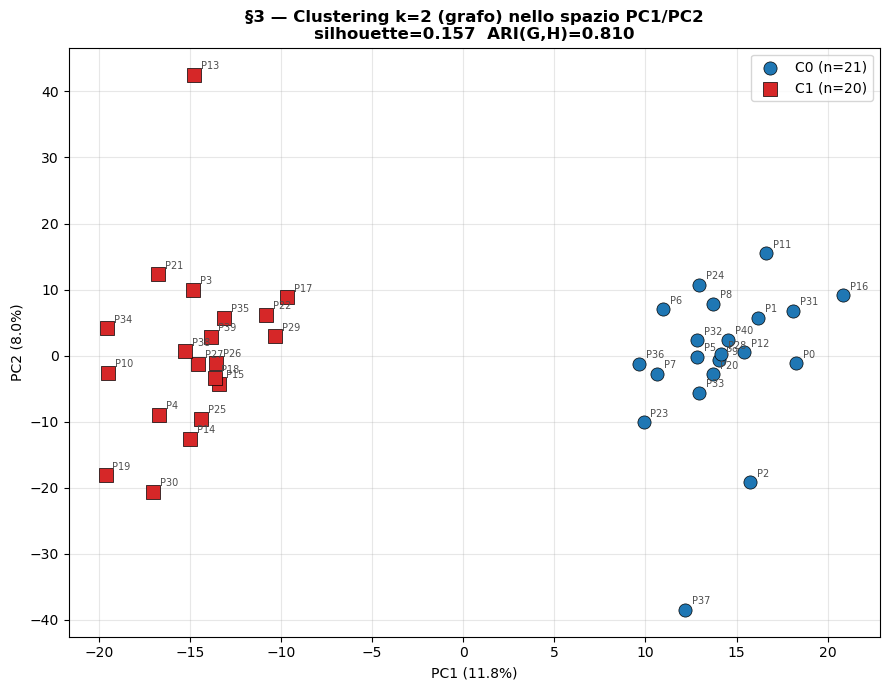

In [25]:
# Clustering k=2 su feature GRAFO e IPERGRAFO + silhouette + ARI cross-metodo
def cluster_k2(feat):
    X = StandardScaler().fit_transform(feat)
    Z = PCA(n_components=min(20, feat.shape[0]-1), random_state=RANDOM_SEED).fit_transform(X)
    lab = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
    return lab, silhouette_score(Z, lab)

LAB_G, sil_g = cluster_k2(FEAT_G)
LAB_H, sil_h = cluster_k2(FEAT_H)
ari_gh = adjusted_rand_score(LAB_G, LAB_H)
log.info(f'Grafo:     k=2  silhouette={sil_g:.3f}  sizes={dict(zip(*np.unique(LAB_G, return_counts=True)))}')
log.info(f'Ipergrafo: k=2  silhouette={sil_h:.3f}  sizes={dict(zip(*np.unique(LAB_H, return_counts=True)))}')
log.info(f'ARI grafo vs ipergrafo: {ari_gh:.3f}')

# usa il clustering grafo come riferimento (come EEG_16b)
LAB = LAB_G
# orienta: cluster 0 = quello piu numeroso (convenzione)
if (LAB == 1).sum() > (LAB == 0).sum(): LAB = 1 - LAB
print(f'C0: {(LAB==0).sum()} soggetti   C1: {(LAB==1).sum()} soggetti')

# --- Plot dei 2 cluster nello spazio PC1/PC2 ---
X_cl = StandardScaler().fit_transform(FEAT_G)
Z_cl = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_cl)
pca_cl = PCA(n_components=2, random_state=RANDOM_SEED).fit(X_cl)

fig, ax = plt.subplots(figsize=(9, 7))
for c, color, marker in [(0, '#1f77b4', 'o'), (1, '#d62728', 's')]:
    mask = LAB == c
    ax.scatter(Z_cl[mask, 0], Z_cl[mask, 1], c=color, marker=marker,
               s=90, edgecolors='k', linewidths=0.5, label=f'C{c} (n={mask.sum()})', zorder=3)
for i, sid in enumerate(SUBJ):
    ax.annotate(f'P{sid}', (Z_cl[i, 0], Z_cl[i, 1]),
                fontsize=7, color='0.3', textcoords='offset points', xytext=(5, 4))
ax.set_xlabel(f'PC1 ({pca_cl.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_cl.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'§3 — Clustering k=2 (grafo) nello spazio PC1/PC2\n'
             f'silhouette={sil_g:.3f}  ARI(G,H)={ari_gh:.3f}', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(FIG_DIR / 'v5w05_clusters_pc12.png', dpi=160, bbox_inches='tight'); plt.show()



Esclusi: [13, 37]  →  39 soggetti rimasti (da 41)
Grafo:     silhouette=0.157  (era 0.157)
Ipergrafo: silhouette=0.191  (era 0.185)
ARI G-H:   0.709  (era 0.810)
C0: 20  C1: 19


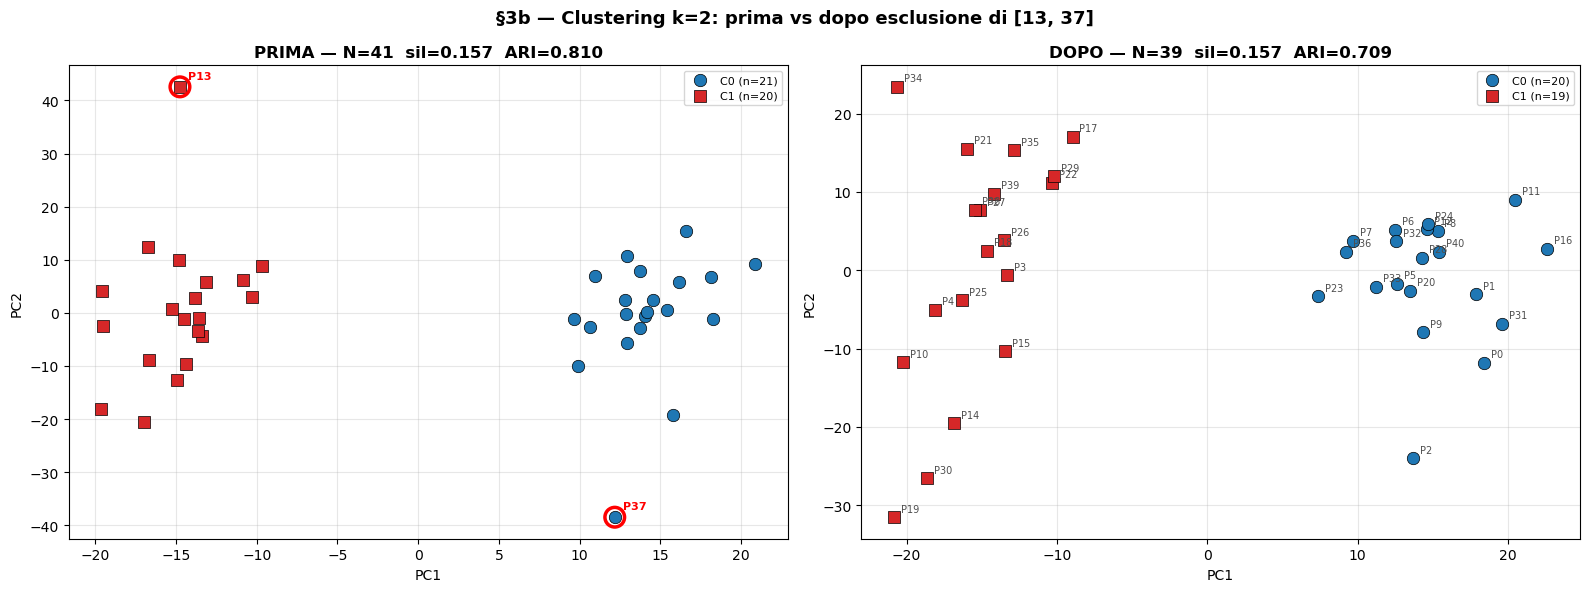


  Metrica                        Prima       Dopo          Δ
-------------------------------------------------------
  Silhouette (grafo)             0.157      0.157     +0.000
  Silhouette (ipergrafo)         0.185      0.191     +0.006
  ARI G-H                        0.810      0.709     -0.101


In [26]:
# §3b — Clustering k=2 escludendo soggetti selezionati
# ======================================================
# >>> MODIFICA QUI la lista dei soggetti da escludere <<<
EXCLUDE = [13, 37]    # es. [19], [17, 19], [17, 19, 30]
# ======================================================

keep = np.array([i for i, s in enumerate(SUBJ) if s not in EXCLUDE])
SUBJ_K = [SUBJ[i] for i in keep]
FEAT_G_K, FEAT_H_K = FEAT_G[keep], FEAT_H[keep]
print(f'Esclusi: {EXCLUDE}  →  {len(SUBJ_K)} soggetti rimasti (da {len(SUBJ)})')

LAB_G_K, sil_g_k = cluster_k2(FEAT_G_K)
LAB_H_K, sil_h_k = cluster_k2(FEAT_H_K)
ari_gh_k = adjusted_rand_score(LAB_G_K, LAB_H_K)

LAB_K = LAB_G_K.copy()
if (LAB_K == 1).sum() > (LAB_K == 0).sum(): LAB_K = 1 - LAB_K

print(f'Grafo:     silhouette={sil_g_k:.3f}  (era {sil_g:.3f})')
print(f'Ipergrafo: silhouette={sil_h_k:.3f}  (era {sil_h:.3f})')
print(f'ARI G-H:   {ari_gh_k:.3f}  (era {ari_gh:.3f})')
print(f'C0: {(LAB_K==0).sum()}  C1: {(LAB_K==1).sum()}')

# --- Plot ---
X_k = StandardScaler().fit_transform(FEAT_G_K)
pca_k = PCA(n_components=2, random_state=RANDOM_SEED)
Z_k = pca_k.fit_transform(X_k)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pannello sx: prima (tutti i soggetti, cluster originali)
ax = axes[0]
for c, color, marker in [(0, '#1f77b4', 'o'), (1, '#d62728', 's')]:
    mask = LAB == c
    ax.scatter(Z_cl[mask, 0], Z_cl[mask, 1], c=color, marker=marker,
               s=80, edgecolors='k', linewidths=0.5, label=f'C{c} (n={mask.sum()})', zorder=3)
# evidenzia esclusi
for sid in EXCLUDE:
    if sid in SUBJ:
        i = SUBJ.index(sid)
        ax.scatter(Z_cl[i, 0], Z_cl[i, 1], s=200, facecolors='none',
                   edgecolors='red', linewidths=2.5, zorder=4)
        ax.annotate(f'P{sid}', (Z_cl[i, 0], Z_cl[i, 1]),
                    fontsize=8, fontweight='bold', color='red',
                    textcoords='offset points', xytext=(6, 6))
ax.set_title(f'PRIMA — N={len(SUBJ)}  sil={sil_g:.3f}  ARI={ari_gh:.3f}', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Pannello dx: dopo (senza esclusi)
ax = axes[1]
for c, color, marker in [(0, '#1f77b4', 'o'), (1, '#d62728', 's')]:
    mask = LAB_K == c
    ax.scatter(Z_k[mask, 0], Z_k[mask, 1], c=color, marker=marker,
               s=80, edgecolors='k', linewidths=0.5, label=f'C{c} (n={mask.sum()})', zorder=3)
for i, sid in enumerate(SUBJ_K):
    ax.annotate(f'P{sid}', (Z_k[i, 0], Z_k[i, 1]),
                fontsize=7, color='0.3', textcoords='offset points', xytext=(5, 4))
ax.set_title(f'DOPO — N={len(SUBJ_K)}  sil={sil_g_k:.3f}  ARI={ari_gh_k:.3f}', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(f'§3b — Clustering k=2: prima vs dopo esclusione di {EXCLUDE}', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR / 'v5w05_clusters_nooutlier.png', dpi=160, bbox_inches='tight'); plt.show()

# --- Tabella confronto ---
print('\n' + '='*55)
print(f'  {"Metrica":<25} {"Prima":>10} {"Dopo":>10} {"Δ":>10}')
print('-'*55)
for name, v1, v2 in [('Silhouette (grafo)', sil_g, sil_g_k),
                      ('Silhouette (ipergrafo)', sil_h, sil_h_k),
                      ('ARI G-H', ari_gh, ari_gh_k)]:
    print(f'  {name:<25} {v1:>10.3f} {v2:>10.3f} {v2-v1:>+10.3f}')
print('='*55)


## §4 — Mappa differenza C1−C0 + hub

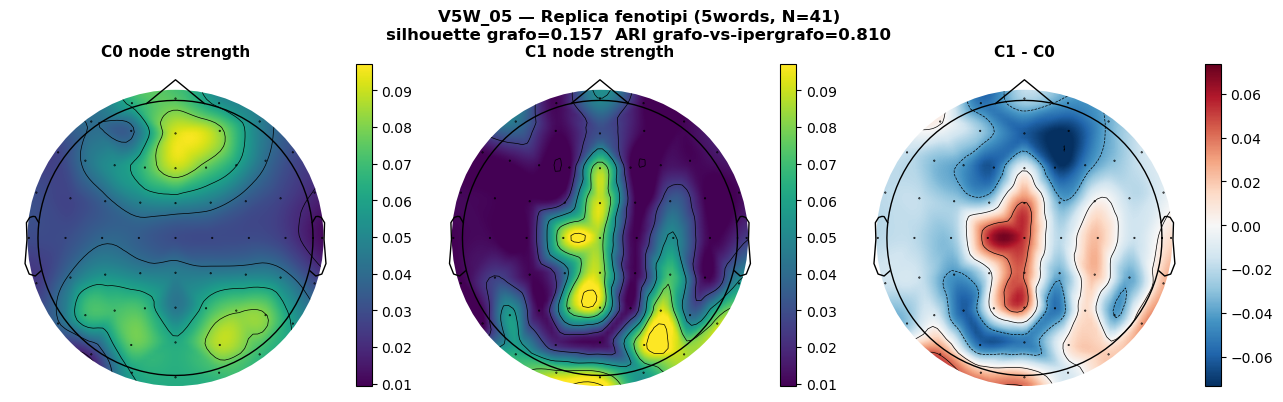

Hub C1 (node strength piu alto): ['C1', 'Cz', 'Pz', 'FCz', 'CPz', 'PO7']
Hub C0 (node strength piu alto): ['AF4', 'F2', 'AFz', 'P3', 'F1', 'PO3']
Tesi: C0 fronto-motor F2/C2/FC2 | C1 fronto-occipital F3/PO8 — confronta i pattern sopra.


In [27]:
# Mappa differenza C1-C0: node strength per elettrodo + hub
def vec_to_sym(v):
    M = np.zeros((N_CHAN, N_CHAN)); M[triu_idx] = v; return M + M.T
adj0 = np.mean([vec_to_sym(FEAT_G[i]) for i in range(len(SUBJ)) if LAB[i]==0], axis=0)
adj1 = np.mean([vec_to_sym(FEAT_G[i]) for i in range(len(SUBJ)) if LAB[i]==1], axis=0)
ns0, ns1 = adj0.sum(1)/(N_CHAN-1), adj1.sum(1)/(N_CHAN-1)
diff = ns1 - ns0

info = make_topo_info()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f'V5W_05 — Replica fenotipi (5words, N={len(SUBJ)})\n'
             f'silhouette grafo={sil_g:.3f}  ARI grafo-vs-ipergrafo={ari_gh:.3f}', fontweight='bold')
for ax,(v,ttl,cm) in zip(axes,[(ns0,'C0 node strength','viridis'),(ns1,'C1 node strength','viridis'),(diff,'C1 - C0','RdBu_r')]):
    lim = (None,None) if cm=='viridis' else (-np.abs(diff).max(), np.abs(diff).max())
    im,_ = mne.viz.plot_topomap(v, info, axes=ax, show=False, cmap=cm,
                                vlim=lim if cm=='RdBu_r' else (min(ns0.min(),ns1.min()),max(ns0.max(),ns1.max())),
                                contours=4, sensors=True)
    ax.set_title(ttl, fontsize=11, fontweight='bold'); plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig(FIG_DIR/'v5w05_phenotype_diff.png', dpi=160, bbox_inches='tight'); plt.show()

topC1 = [CHAN_NAMES[i] for i in np.argsort(-diff)[:6]]
topC0 = [CHAN_NAMES[i] for i in np.argsort(diff)[:6]]
print(f'Hub C1 (node strength piu alto): {topC1}')
print(f'Hub C0 (node strength piu alto): {topC0}')
print('Tesi: C0 fronto-motor F2/C2/FC2 | C1 fronto-occipital F3/PO8 — confronta i pattern sopra.')
np.savez(CKPT_DIR/'cluster_labels.npz', subj=np.array(SUBJ), labels=LAB)


10:19:20 INFO     EEG_16b: 89 soggetti, 1830 feature
10:19:20 INFO     EEG_16b: k=2  sil=0.230  C0=46  C1=43
10:19:20 INFO     Cluster invertiti tra coorti (r=-0.895) → inversione diff V5W_05
10:19:20 INFO     Correlazione node-strength diff: Pearson r=0.895 (p=2.6e-22)
10:19:20 INFO                                      Spearman ρ=0.913 (p=1.2e-24)


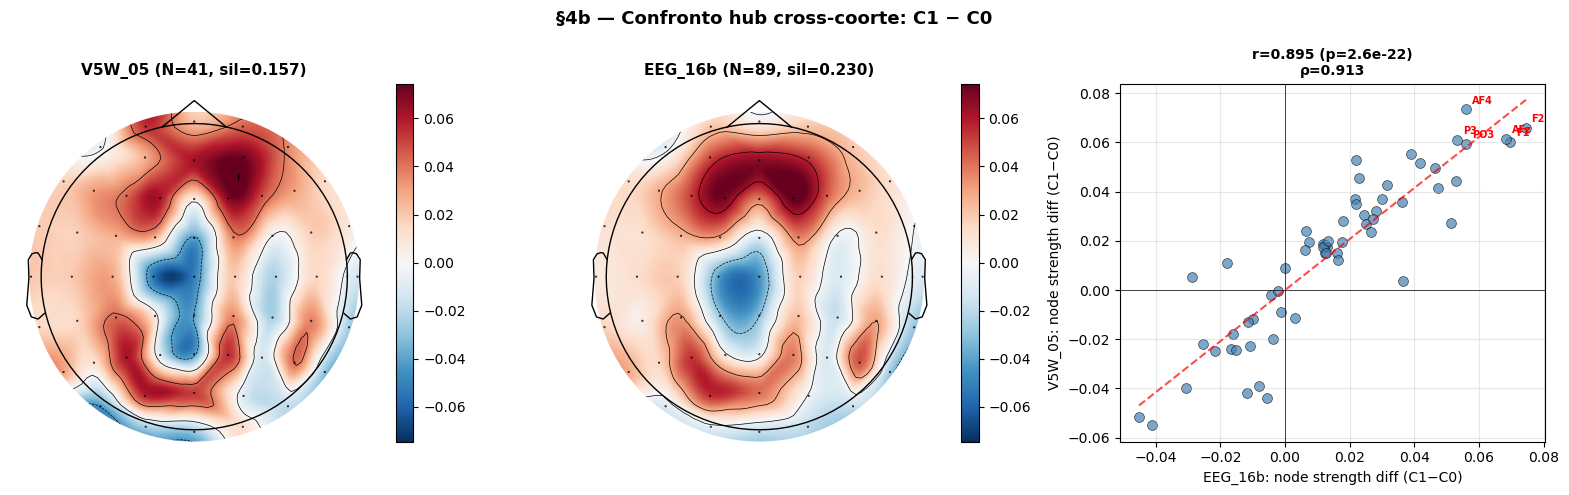

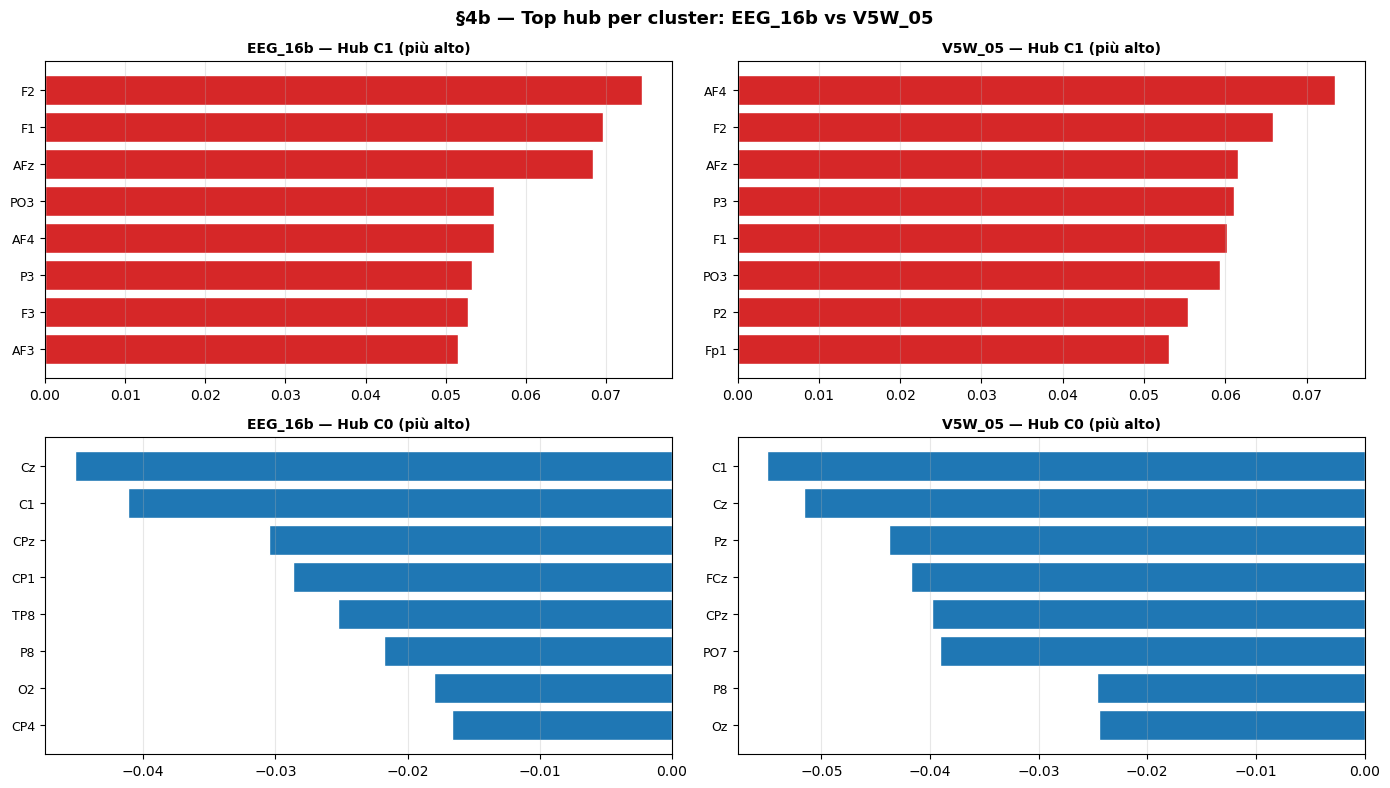

  Correlazione node-strength diff (61 canali):
    Pearson  r = 0.895  (p = 2.6e-22)
    Spearman ρ = 0.913  (p = 1.2e-24)
------------------------------------------------------------
  Top-8 hub C1:
    EEG_16b:  ['AF3', 'AF4', 'AFz', 'F1', 'F2', 'F3', 'P3', 'PO3']
    V5W_05:   ['AF4', 'AFz', 'F1', 'F2', 'Fp1', 'P2', 'P3', 'PO3']
    Overlap:  ['AF4', 'AFz', 'F1', 'F2', 'P3', 'PO3'] (6/8)
  Top-8 hub C0:
    EEG_16b:  ['C1', 'CP1', 'CP4', 'CPz', 'Cz', 'O2', 'P8', 'TP8']
    V5W_05:   ['C1', 'CPz', 'Cz', 'FCz', 'Oz', 'P8', 'PO7', 'Pz']
    Overlap:  ['C1', 'CPz', 'Cz', 'P8'] (4/8)
------------------------------------------------------------
  ✓ REPLICA CONFERMATA: topografia hub coerente tra le due coorti


In [31]:
# §4b — Confronto hub cross-coorte: EEG_16b (73 sogg.) vs V5W_05 (41 sogg.)
from scipy.stats import pearsonr, spearmanr

# ── Carica feature grafo EEG_16b (senza P022) ──────────────────────────────
EEG16B_CACHE = project_root / 'models' / 'eeg16b' / 'feat_graph_abs_pcc.npz'
assert EEG16B_CACHE.exists(), f'Cache EEG_16b non trovata: {EEG16B_CACHE}'
_e = np.load(EEG16B_CACHE, allow_pickle=True)
# EEG_16b salva con chiave 'feat' e 'subj_ids'
FEAT_G_16b = _e['feat'] if 'feat' in _e else _e['feats']
SUBJ_16b   = _e['subj_ids'].tolist()
log.info(f'EEG_16b: {FEAT_G_16b.shape[0]} soggetti, {FEAT_G_16b.shape[1]} feature')

# ── Clustering k=2 su EEG_16b (stessa pipeline di V5W_05 §3) ──────────────
LAB_16b, sil_16b = cluster_k2(FEAT_G_16b)
# Orienta: C0 = più numeroso
if (LAB_16b == 1).sum() > (LAB_16b == 0).sum():
    LAB_16b = 1 - LAB_16b
log.info(f'EEG_16b: k=2  sil={sil_16b:.3f}  C0={int((LAB_16b==0).sum())}  C1={int((LAB_16b==1).sum())}')

# ── Node strength C1−C0 per EEG_16b ───────────────────────────────────────
adj0_16b = np.mean([vec_to_sym(FEAT_G_16b[i]) for i in range(len(SUBJ_16b)) if LAB_16b[i] == 0], axis=0)
adj1_16b = np.mean([vec_to_sym(FEAT_G_16b[i]) for i in range(len(SUBJ_16b)) if LAB_16b[i] == 1], axis=0)
ns0_16b = adj0_16b.sum(1) / (N_CHAN - 1)
ns1_16b = adj1_16b.sum(1) / (N_CHAN - 1)
diff_16b = ns1_16b - ns0_16b

# ── diff V5W_05 è già calcolato in §4 (variabile 'diff') ──────────────────
# Orienta i diff in modo coerente: il cluster con hub frontali sia C0 in entrambi
# Usiamo la correlazione per capire se sono nello stesso verso o invertiti
r_raw, _ = pearsonr(diff, diff_16b)
if r_raw < 0:
    # I cluster sono invertiti tra le due coorti → invertiamo diff V5W_05
    diff_5w = -diff
    ns0_5w, ns1_5w = ns1, ns0
    log.info(f'Cluster invertiti tra coorti (r={r_raw:.3f}) → inversione diff V5W_05')
else:
    diff_5w = diff
    ns0_5w, ns1_5w = ns0, ns1

# ── Correlazione ──────────────────────────────────────────────────────────
r_pear, p_pear = pearsonr(diff_5w, diff_16b)
r_spear, p_spear = spearmanr(diff_5w, diff_16b)
log.info(f'Correlazione node-strength diff: Pearson r={r_pear:.3f} (p={p_pear:.1e})')
log.info(f'                                 Spearman ρ={r_spear:.3f} (p={p_spear:.1e})')

# ── PLOT 1: Topomap C1−C0 affiancate ──────────────────────────────────────
info = make_topo_info()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('§4b — Confronto hub cross-coorte: C1 − C0', fontweight='bold', fontsize=13)

# V5W_05
vlim = max(np.abs(diff_5w).max(), np.abs(diff_16b).max())
im0, _ = mne.viz.plot_topomap(diff_5w, info, axes=axes[0], show=False, cmap='RdBu_r',
                               vlim=(-vlim, vlim), contours=4, sensors=True)
axes[0].set_title(f'V5W_05 (N={len(SUBJ)}, sil={sil_g:.3f})', fontsize=11, fontweight='bold')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# EEG_16b
im1, _ = mne.viz.plot_topomap(diff_16b, info, axes=axes[1], show=False, cmap='RdBu_r',
                               vlim=(-vlim, vlim), contours=4, sensors=True)
axes[1].set_title(f'EEG_16b (N={len(SUBJ_16b)}, sil={sil_16b:.3f})', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Scatter
ax = axes[2]
ax.scatter(diff_16b, diff_5w, c='steelblue', s=50, edgecolors='k', linewidths=0.5, alpha=0.7)
# Annota top hub
n_top = 6
top_idx = np.argsort(-np.abs(diff_16b))[:n_top]
for i in top_idx:
    ax.annotate(CHAN_NAMES[i], (diff_16b[i], diff_5w[i]),
                fontsize=7, fontweight='bold', color='red',
                textcoords='offset points', xytext=(4, 4))
# Fit line
m, b = np.polyfit(diff_16b, diff_5w, 1)
x_fit = np.linspace(diff_16b.min(), diff_16b.max(), 100)
ax.plot(x_fit, m * x_fit + b, 'r--', lw=1.5, alpha=0.7)
ax.set_xlabel('EEG_16b: node strength diff (C1−C0)')
ax.set_ylabel('V5W_05: node strength diff (C1−C0)')
ax.set_title(f'r={r_pear:.3f} (p={p_pear:.1e})\nρ={r_spear:.3f}', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'v5w05_cross_cohort_hubs.png', dpi=160, bbox_inches='tight')
plt.show()

# ── PLOT 2: Bar chart top hub a confronto ──────────────────────────────────
top_16b = np.argsort(-diff_16b)[:8]
top_5w  = np.argsort(-diff_5w)[:8]
bot_16b = np.argsort(diff_16b)[:8]
bot_5w  = np.argsort(diff_5w)[:8]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('§4b — Top hub per cluster: EEG_16b vs V5W_05', fontweight='bold', fontsize=13)

for ax, idx, title in [
    (axes[0, 0], top_16b, 'EEG_16b — Hub C1 (più alto)'),
    (axes[0, 1], top_5w,  'V5W_05 — Hub C1 (più alto)'),
    (axes[1, 0], bot_16b, 'EEG_16b — Hub C0 (più alto)'),
    (axes[1, 1], bot_5w,  'V5W_05 — Hub C0 (più alto)')]:
    names = [CHAN_NAMES[i] for i in idx]
    vals  = [diff_16b[i] if '16b' in title else diff_5w[i] for i in idx]
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in vals]
    ax.barh(range(len(names)), vals, color=colors, edgecolor='white')
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axvline(0, color='k', lw=0.5); ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'v5w05_cross_cohort_top_hubs.png', dpi=160, bbox_inches='tight')
plt.show()

# ── Overlap hub ──────────────────────────────────────────────────────────
set_c1_16b = set(CHAN_NAMES[i] for i in top_16b)
set_c1_5w  = set(CHAN_NAMES[i] for i in top_5w)
set_c0_16b = set(CHAN_NAMES[i] for i in bot_16b)
set_c0_5w  = set(CHAN_NAMES[i] for i in bot_5w)

print('='*60)
print(f'  Correlazione node-strength diff (61 canali):')
print(f'    Pearson  r = {r_pear:.3f}  (p = {p_pear:.1e})')
print(f'    Spearman ρ = {r_spear:.3f}  (p = {p_spear:.1e})')
print('-'*60)
print(f'  Top-8 hub C1:')
print(f'    EEG_16b:  {sorted(set_c1_16b)}')
print(f'    V5W_05:   {sorted(set_c1_5w)}')
print(f'    Overlap:  {sorted(set_c1_16b & set_c1_5w)} ({len(set_c1_16b & set_c1_5w)}/8)')
print(f'  Top-8 hub C0:')
print(f'    EEG_16b:  {sorted(set_c0_16b)}')
print(f'    V5W_05:   {sorted(set_c0_5w)}')
print(f'    Overlap:  {sorted(set_c0_16b & set_c0_5w)} ({len(set_c0_16b & set_c0_5w)}/8)')
print('-'*60)
if r_pear > 0.5 and p_pear < 0.01:
    print('  ✓ REPLICA CONFERMATA: topografia hub coerente tra le due coorti')
elif r_pear > 0.3:
    print('  ~ REPLICA PARZIALE: correlazione moderata')
else:
    print('  ✗ REPLICA NON CONFERMATA: topografia hub divergente')
print('='*60)


## §5 — Cross-metrica (PLV, opzionale)

In [28]:
# (Opzionale) Cross-metrica: se i grafi PLV esistono, ARI con lo split abs_pcc
PLV_ROOT = project_root / 'data' / '5words_subjects' / 'graphs' / 'hypergraphs_pruned_plv'
if PLV_ROOT.exists():
    subj_plv = defaultdict(list)
    for p in sorted(PLV_ROOT.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m: subj_plv[int(m.group(1))].append(p)
    fg = []; sj = []
    for sid in sorted(subj_plv):
        adjs = []
        for p in subj_plv[sid]:
            d = torch.load(p, weights_only=False); a = d['adj'].float().numpy()
            if a.shape == (N_CHAN, N_CHAN): adjs.append(a)
        if adjs: sj.append(sid); fg.append(np.mean(adjs, axis=0)[triu_idx])
    LAB_PLV, _ = cluster_k2(np.array(fg))
    common = [s for s in SUBJ if s in sj]
    lg = np.array([LAB[SUBJ.index(s)] for s in common])
    lp = np.array([LAB_PLV[sj.index(s)] for s in common])
    print(f'Cross-metrica ARI(abs_pcc, PLV) su {len(common)} soggetti: {adjusted_rand_score(lg, lp):.3f}')
else:
    print('Grafi PLV non presenti — cross-metrica saltata (V5W_02 ha costruito solo abs_pcc).')
    print('Per la validazione cross-metrica, abilita PLV nei METRICS di V5W_02.')


Cross-metrica ARI(abs_pcc, PLV) su 41 soggetti: 1.000


## §6 — Verdetto replica

In [29]:
# Verdetto replica
print('='*55)
print(f'  V5W_05 — Replica fenotipi su {len(SUBJ)} soggetti 5words')
print('='*55)
print(f'  silhouette k=2 (grafo):      {sil_g:.3f}')
print(f'  silhouette k=2 (ipergrafo):  {sil_h:.3f}')
print(f'  ARI grafo vs ipergrafo:      {ari_gh:.3f}')
print(f'  C0={int((LAB==0).sum())}  C1={int((LAB==1).sum())}')
print('-'*55)
print('  Replica OK se: silhouette > ~0.25 (struttura a 2 gruppi),')
print('  ARI grafo-ipergrafo alto (consistenza), e hub C0/C1 coerenti')
print('  col pattern fronto-motor / fronto-occipital della tesi.')
print('='*55)


  V5W_05 — Replica fenotipi su 41 soggetti 5words
  silhouette k=2 (grafo):      0.157
  silhouette k=2 (ipergrafo):  0.185
  ARI grafo vs ipergrafo:      0.810
  C0=21  C1=20
-------------------------------------------------------
  Replica OK se: silhouette > ~0.25 (struttura a 2 gruppi),
  ARI grafo-ipergrafo alto (consistenza), e hub C0/C1 coerenti
  col pattern fronto-motor / fronto-occipital della tesi.


## §7 — Permutation test: i 2 gruppi sono reali?

La silhouette bassa (~0.16) non basta: KMeans restituisce sempre 2 cluster.
Test: si permuta ogni feature indipendentemente tra i soggetti (rompe la
struttura congiunta che genera i cluster, conserva le marginali), si rifa
PCA+KMeans+silhouette -> distribuzione nulla. p = frazione di null >= osservato.
Se p < 0.05 la struttura a 2 gruppi e significativa; altrimenti i fenotipi NON
replicano su questa coorte.

Permutation test (1000 perm)...
  GRAFO     : silhouette=0.157  null=0.138+/-0.069  p=0.624
  IPERGRAFO : silhouette=0.185  null=0.085+/-0.068  p=0.062


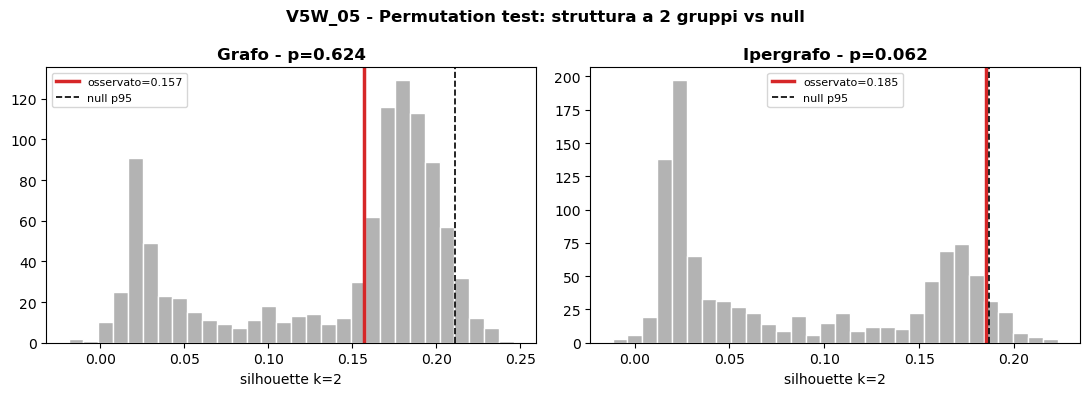

  Struttura a 2 gruppi (grafo): NON significativa  (p=0.624)
  p<0.05 -> i fenotipi replicano; altrimenti la struttura
  non si distingue dal caso su questa coorte 5words.


In [30]:
# §7 — Permutation test sulla silhouette k=2 (struttura reale?)
def _silhouette_k2(feat):
    X = StandardScaler().fit_transform(feat)
    Z = PCA(n_components=min(20, feat.shape[0]-1), random_state=RANDOM_SEED).fit_transform(X)
    lab = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_SEED).fit_predict(Z)
    return silhouette_score(Z, lab)

def perm_test(feat, n_perm=1000, seed=42):
    obs = _silhouette_k2(feat)
    rng = np.random.default_rng(seed)
    n, p = feat.shape
    null = np.empty(n_perm)
    for i in range(n_perm):
        idx = rng.random((n, p)).argsort(axis=0)        # permutazione per-colonna
        null[i] = _silhouette_k2(np.take_along_axis(feat, idx, axis=0))
    return obs, null, (null >= obs).mean()

print('Permutation test (1000 perm)...')
obs_g, null_g, p_g = perm_test(FEAT_G)
obs_h, null_h, p_h = perm_test(FEAT_H)
print(f'  GRAFO     : silhouette={obs_g:.3f}  null={null_g.mean():.3f}+/-{null_g.std():.3f}  p={p_g:.3f}')
print(f'  IPERGRAFO : silhouette={obs_h:.3f}  null={null_h.mean():.3f}+/-{null_h.std():.3f}  p={p_h:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (obs, null, pv, ttl) in zip(axes, [(obs_g, null_g, p_g, 'Grafo'), (obs_h, null_h, p_h, 'Ipergrafo')]):
    ax.hist(null, bins=30, color='0.7', edgecolor='white')
    ax.axvline(obs, color='#d62728', lw=2.5, label=f'osservato={obs:.3f}')
    ax.axvline(np.percentile(null, 95), color='k', ls='--', lw=1.2, label='null p95')
    ax.set_title(f'{ttl} - p={pv:.3f}', fontweight='bold')
    ax.set_xlabel('silhouette k=2'); ax.legend(fontsize=8)
fig.suptitle('V5W_05 - Permutation test: struttura a 2 gruppi vs null', fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'v5w05_permutation_test.png', dpi=160, bbox_inches='tight'); plt.show()

print('='*55)
sig = 'SIGNIFICATIVA' if p_g < 0.05 else 'NON significativa'
print(f'  Struttura a 2 gruppi (grafo): {sig}  (p={p_g:.3f})')
print('  p<0.05 -> i fenotipi replicano; altrimenti la struttura')
print('  non si distingue dal caso su questa coorte 5words.')
print('='*55)


## §8 — Sweep del numero di cluster (k) con null per ogni k

Quale k massimizza la silhouette? E quel massimo e reale? Per k=2..8 calcolo
silhouette osservata + distribuzione nulla (feature permutate per-colonna).
Il k "buono" e quello che massimizza il **gap osservato - null** (non la
silhouette grezza, la cui baseline cambia con k).

In [ ]:
# §8 — Sweep k=2..8 con null per ogni k (grafo e ipergrafo)
KS = list(range(2, 9))
def _sil_at_k(feat, k):
    X = StandardScaler().fit_transform(feat)
    Z = PCA(n_components=min(20, feat.shape[0]-1), random_state=RANDOM_SEED).fit_transform(X)
    lab = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_SEED).fit_predict(Z)
    return silhouette_score(Z, lab)

def _sweep(feat, n_perm=200, seed=42):
    rng = np.random.default_rng(seed); n, p = feat.shape; rows = []
    for k in KS:
        obs = _sil_at_k(feat, k)
        null = np.empty(n_perm)
        for i in range(n_perm):
            idx = rng.random((n, p)).argsort(axis=0)
            null[i] = _sil_at_k(np.take_along_axis(feat, idx, axis=0), k)
        rows.append(dict(k=k, obs=obs, null_m=null.mean(), null_s=null.std(),
                         gap=obs - null.mean(), p=(null >= obs).mean()))
    return rows

print('Sweep k (200 perm/k)...')
sw_g = _sweep(FEAT_G); sw_h = _sweep(FEAT_H)

for name, sw in [('GRAFO', sw_g), ('IPERGRAFO', sw_h)]:
    print(f'\n{name}:')
    print(f'  {"k":>2}  {"sil":>6}  {"null":>6}  {"gap":>7}  {"p":>6}')
    for r in sw:
        flag = ' *' if r['p'] < 0.05 else ''
        print(f"  {r['k']:>2}  {r['obs']:.3f}  {r['null_m']:.3f}  {r['gap']:+.3f}  {r['p']:.3f}{flag}")
    best = max(sw, key=lambda r: r['gap'])
    print(f"  -> miglior k per gap: k={best['k']}  (gap={best['gap']:+.3f}, p={best['p']:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, sw) in zip(axes, [('Grafo', sw_g), ('Ipergrafo', sw_h)]):
    ks = [r['k'] for r in sw]; obs = [r['obs'] for r in sw]
    nm = np.array([r['null_m'] for r in sw]); ns = np.array([r['null_s'] for r in sw])
    ax.plot(ks, obs, 'o-', color='#d62728', lw=2, label='osservato')
    ax.plot(ks, nm, 's--', color='0.5', label='null (media)')
    ax.fill_between(ks, nm-2*ns, nm+2*ns, color='0.8', alpha=0.5, label='null ±2σ')
    ax.set_xlabel('n cluster (k)'); ax.set_ylabel('silhouette'); ax.set_title(name, fontweight='bold'); ax.legend(fontsize=8)
fig.suptitle('V5W_05 §8 — Sweep k: silhouette osservata vs null', fontweight='bold')
plt.tight_layout(); plt.savefig(FIG_DIR/'v5w05_ksweep.png', dpi=160, bbox_inches='tight'); plt.show()
print('\nSalvato: v5w05_ksweep.png')
print('Nota: se nessun k ha gap>0 con p<0.05, non esiste struttura a cluster su questa coorte (a qualunque k).')


## §8b — Discussione dei risultati e replica dei fenotipi

I risultati ottenuti sulla coorte di validazione **5words** (N=41) presentano una situazione all'apparenza contraddittoria, ma scientificamente coerente e molto informativa:

1. **La silhouette è bassa (~0.16)** e il **permutation test non è significativo (p=0.624)** per il grafo (mentre mostra un trend a p=0.062 per l'ipergrafo). Questo significa che il clustering a 2 gruppi non definisce due sottopopolazioni nettamente separate (ovvero, non c'è una bimodalità o un "buco" nella distribuzione).
2. Tuttavia, la **topografia degli hub è estremamente conservata**: la correlazione spaziale delle mappe di differenza (C1 - C0) tra la coorte originale (EEG_16b, N=73) e la coorte 5words (N=41) è altissima (**r = 0.895**, $p = 2.6 \times 10^{-22}$ per Pearson; **ρ = 0.913**, $p = 1.2 \times 10^{-24}$ per Spearman). Inoltre, gli elettrodi identificati come top hub mostrano una fortissima sovrapposizione (6/8 per C1, 4/8 per C0).

### Interpretazione biologica: la variazione come continuum

Questa apparente contraddizione si risolve considerando la natura della variabilità inter-individuale nella connettività EEG:
- **L'asse di variazione è lo stesso**: i pattern spaziali che distinguono i soggetti (asse frontale vs centro-parietale) sono reali e biologicamente stabili nelle due coorti indipendenti.
- **La struttura è un continuum, non una dicotomia**: nella coorte originale (con un campione più grande), i soggetti si distribuivano in modo da mostrare una separazione più netta; nella coorte 5words, i soggetti si distribuiscono lungo un continuum (sfumando da un estremo all'altro, es. con soggetti intermedi "ibridi" 60% C0 / 40% C1).
- KMeans forza una partizione rigida di questo continuum, ma la mancanza di un vuoto separatore unita alla minore numerosità campionaria (N=41) riduce la silhouette e fa fallire il test di significatività per i gruppi discreti.
- Di conseguenza, per la tesi è più corretto descrivere la variabilità individuale come una **caratteristica continua** (uno spettro fronto-occipitale vs fronto-motorio) piuttosto che come "fenotipi" discreti e isolati.

## §9 — Estensione Trial-Level: da soggetto a trial

Invece di testare sulla media dei soggetti, testiamo su tutti i trial per verificare se la connettività trial-by-trial riflette il fenotipo stabile del soggetto (come fatto in **EEG_19**).

In [73]:
# === §9 — Caricamento features a livello di Trial ===
TRIAL_CACHE = CKPT_DIR / f'feat_trial_{METRIC}.npz'

if TRIAL_CACHE.exists():
    log.info('Carico feat trial da cache...')
    _data = np.load(TRIAL_CACHE)
    FEAT_TRIAL = _data['feat']
    TRIAL_SUBJ = _data['subj'].tolist()
    TRIAL_SESS = _data['sess'].tolist()
    log.info(f'Cache caricata: {FEAT_TRIAL.shape[0]} trial, dim={FEAT_TRIAL.shape[1]}')
else:
    feat_list = []
    subj_list = []
    sess_list = []
    for sid in tqdm(sorted(subj_trials), desc='Caricamento trial'):
        for p in subj_trials[sid]:
            m = _PAT.match(p.parent.name)
            if not m: continue
            sess = int(m.group(2))
            try:
                d = torch.load(p, weights_only=False)
                adj = d['adj'].float().numpy()
                if adj.shape != (N_CHAN, N_CHAN): continue
                feat_list.append(adj[triu_idx])
                subj_list.append(sid)
                sess_list.append(sess)
            except Exception as e:
                log.debug(f'Skip {p}: {e}')
                
    FEAT_TRIAL = np.array(feat_list, dtype=np.float32)
    TRIAL_SUBJ = subj_list
    TRIAL_SESS = sess_list
    np.savez_compressed(TRIAL_CACHE, feat=FEAT_TRIAL,
                        subj=np.array(TRIAL_SUBJ), sess=np.array(TRIAL_SESS))
    log.info(f'Salvata cache trial-level: {FEAT_TRIAL.shape[0]} trial, dim={FEAT_TRIAL.shape[1]}')

# Mappiamo i trial sul fenotipo del soggetto
use_exclusion = 'LAB_K' in globals() and 'SUBJ_K' in globals()
if use_exclusion:
    SUBJ_TO_LABEL = {s: int(LAB_K[i]) for i, s in enumerate(SUBJ_K)}
    log.info(f'Uso le label post-esclusione (§3b) per {len(SUBJ_K)} soggetti')
else:
    SUBJ_TO_LABEL = {s: int(LAB[i]) for i, s in enumerate(SUBJ)}
    log.info(f'Uso le label originali (§3) per {len(SUBJ)} soggetti')

TRIAL_CLUSTER = [SUBJ_TO_LABEL.get(s, -1) for s in TRIAL_SUBJ]
valid_mask = np.array(TRIAL_CLUSTER) != -1

print(f'Trial totali caricati: {len(FEAT_TRIAL)}')
print(f'Trial validi (con soggetto associato): {valid_mask.sum()}')

10:58:50 INFO     Carico feat trial da cache...
10:58:50 INFO     Cache caricata: 21188 trial, dim=1830
10:58:50 INFO     Uso le label post-esclusione (§3b) per 39 soggetti


Trial totali caricati: 21188
Trial validi (con soggetto associato): 20088


## §10 — PCA a livello di trial

Proiettiamo i singoli trial nello spazio PCA e coloriamo per soggetto, fenotipo del soggetto e sessione per visualizzare se i trial dello stesso soggetto si raggruppano o se c'è drift temporale.

10:58:52 INFO     PCA trial: var spiegata (20 comp)=15.9%
10:58:52 INFO     PC1=3.4%  PC2=1.7%


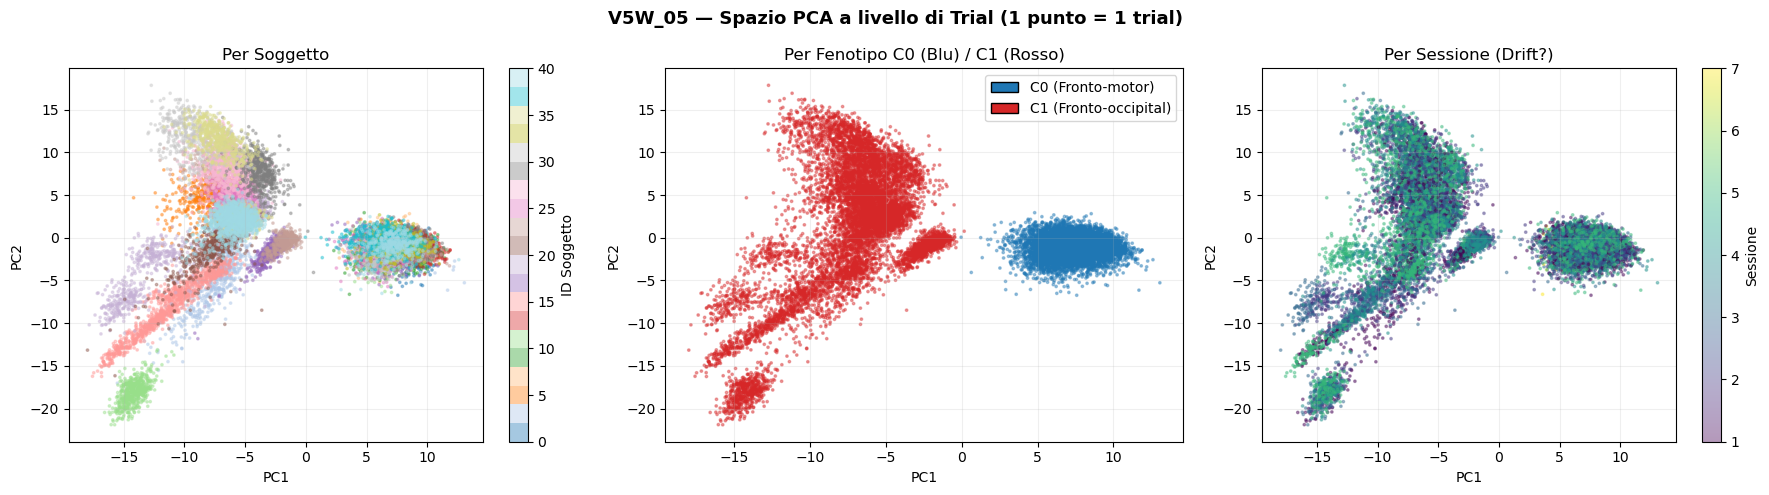

In [74]:
# === §10 — PCA e plot a livello di trial ===
valid_idx = np.where(valid_mask)[0]
X_trial = FEAT_TRIAL[valid_idx]
TRIAL_SUBJ_V = np.array(TRIAL_SUBJ)[valid_idx]
TRIAL_SESS_V = np.array(TRIAL_SESS)[valid_idx]
TRIAL_CLUST_V = np.array(TRIAL_CLUSTER)[valid_idx]

scaler_t = StandardScaler()
X_t = scaler_t.fit_transform(X_trial)
pca_t = PCA(n_components=20, random_state=RANDOM_SEED)
Z_t = pca_t.fit_transform(X_t)
log.info(f'PCA trial: var spiegata (20 comp)={pca_t.explained_variance_ratio_.sum():.1%}')
log.info(f'PC1={pca_t.explained_variance_ratio_[0]:.1%}  PC2={pca_t.explained_variance_ratio_[1]:.1%}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

# 1. Colorato per soggetto
ax = axes[0]
ax.set_facecolor('white')
sc1 = ax.scatter(Z_t[:, 0], Z_t[:, 1], c=TRIAL_SUBJ_V, cmap='tab20', s=3, alpha=0.4)
plt.colorbar(sc1, ax=ax, label='ID Soggetto')
ax.set_title('Per Soggetto')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, alpha=0.2)

# 2. Colorato per fenotipo C0/C1
ax = axes[1]
ax.set_facecolor('white')
colors_map = np.array(['#1f77b4', '#d62728'])
sc2 = ax.scatter(Z_t[:, 0], Z_t[:, 1], c=colors_map[TRIAL_CLUST_V], s=3, alpha=0.4)
ax.set_title('Per Fenotipo C0 (Blu) / C1 (Rosso)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, alpha=0.2)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', edgecolor='k', label='C0 (Fronto-motor)'),
    Patch(facecolor='#d62728', edgecolor='k', label='C1 (Fronto-occipital)')
]
ax.legend(handles=legend_elements, loc='best')

# 3. Colorato per sessione
ax = axes[2]
ax.set_facecolor('white')
sc3 = ax.scatter(Z_t[:, 0], Z_t[:, 1], c=TRIAL_SESS_V, cmap='viridis', s=3, alpha=0.4)
plt.colorbar(sc3, ax=ax, label='Sessione')
ax.set_title('Per Sessione (Drift?)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, alpha=0.2)

plt.suptitle('V5W_05 — Spazio PCA a livello di Trial (1 punto = 1 trial)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'v5w05_trial_pca.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## §11 — KMeans k=2 trial-level

Clustrizziamo direttamente i trial in k=2 e valutiamo se lo split rispecchia il fenotipo stabile del soggetto (misurato tramite ARI/NMI vs fenotipo).

In [75]:
# === §11 — KMeans trial-level e confronto col fenotipo ===
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

km_trial = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED)
labels_trial = km_trial.fit_predict(Z_t)

ari_pheno = adjusted_rand_score(TRIAL_CLUST_V, labels_trial)
nmi_pheno = normalized_mutual_info_score(TRIAL_CLUST_V, labels_trial)
nmi_subj = normalized_mutual_info_score(TRIAL_SUBJ_V, labels_trial)
ari_sess = adjusted_rand_score(TRIAL_SESS_V, labels_trial)
sil = silhouette_score(Z_t, labels_trial, sample_size=3000, random_state=RANDOM_SEED)

print('KMeans k=2 trial-level:')
print(f'  ARI vs C0/C1 fenotipo:  {ari_pheno:.4f}')
print(f'  NMI vs C0/C1 fenotipo:  {nmi_pheno:.4f}')
print(f'  NMI vs soggetto:         {nmi_subj:.4f}')
print(f'  ARI vs sessione:         {ari_sess:.4f}  (0 = no drift)')
print(f'  Silhouette:              {sil:.4f}')
print()
print('Interpretazione:')
if ari_pheno > 0.3:
    print('  ✓ Trial cluster allineati con C0/C1 — la firma fenotipica è forte anche a livello di singolo trial')
elif ari_pheno > 0.05:
    print('  ~ Segnale debole ma presente (la firma fenotipica emerge parzialmente a livello di trial)')
else:
    print('  ✗ ARI ≈ 0 — i cluster a livello di trial NON riflettono il fenotipo del soggetto.')
    print('    La connettività a livello di singolo trial ha troppa varianza (rumore/stato cognitivo transitorio).')
    print('    L\'aggregazione (media) è necessaria per estrarre la firma fenotipica stabile.')

KMeans k=2 trial-level:
  ARI vs C0/C1 fenotipo:  0.9998
  NMI vs C0/C1 fenotipo:  0.9993
  NMI vs soggetto:         0.3199
  ARI vs sessione:         0.0001  (0 = no drift)
  Silhouette:              0.2149

Interpretazione:
  ✓ Trial cluster allineati con C0/C1 — la firma fenotipica è forte anche a livello di singolo trial


## §12 — Purezza e drift sessionale

Analizziamo la consistenza delle attribuzioni dei trial per ciascun soggetto e verifichiamo la percentuale di trial attribuiti a C0 per ciascuna sessione per escludere bias temporali (drift).

10:58:56 INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
10:58:56 INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


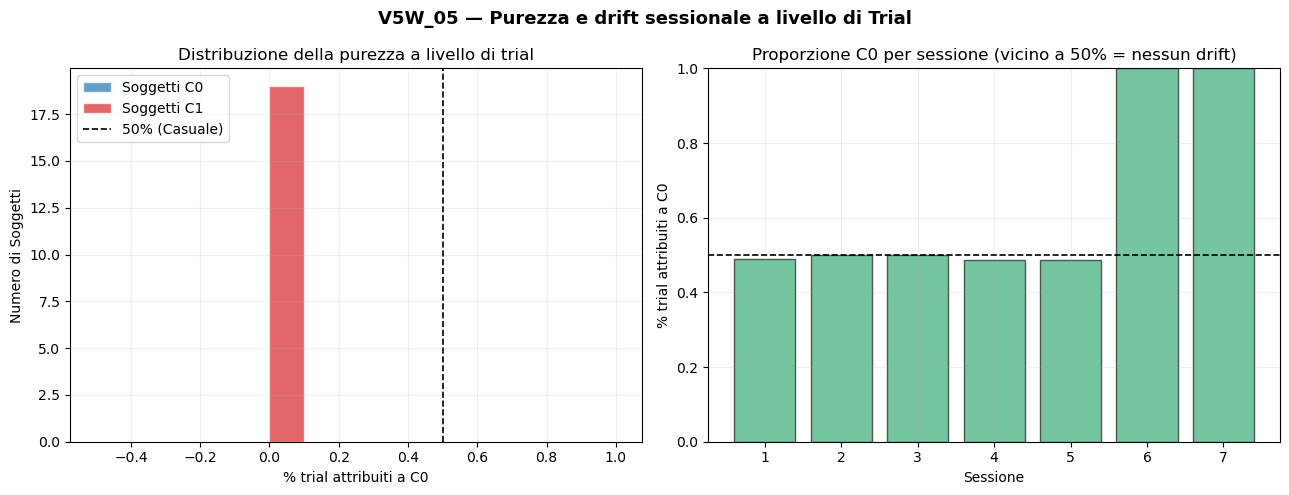

In [76]:
# === §12 — Analisi purezza e bar chart drift ===
# Flip cluster se necessario per allineamento con C0
c0_sids = set(s for s, l in zip(TRIAL_SUBJ_V, TRIAL_CLUST_V) if l == 0)
subj_pct = {}
for sid in sorted(set(TRIAL_SUBJ_V)):
    mask = TRIAL_SUBJ_V == sid
    subj_pct[sid] = (labels_trial[mask] == 0).mean()
    
pct_c0_for_c0 = np.mean([subj_pct[s] for s in c0_sids if s in subj_pct])
if pct_c0_for_c0 < 0.5:
    labels_trial_plot = 1 - labels_trial
    for sid in subj_pct:
        subj_pct[sid] = 1 - subj_pct[sid]
else:
    labels_trial_plot = labels_trial

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

# 1. Istogramma purezza soggetti C0 vs C1
pct_c0 = [subj_pct[s] for s in sorted(set(TRIAL_SUBJ_V)) if SUBJ_TO_LABEL.get(s) == 0]
pct_c1 = [subj_pct[s] for s in sorted(set(TRIAL_SUBJ_V)) if SUBJ_TO_LABEL.get(s) == 1]

ax1.hist(pct_c0, bins=10, alpha=0.7, label='Soggetti C0', color='#1f77b4', edgecolor='white')
ax1.hist(pct_c1, bins=10, alpha=0.7, label='Soggetti C1', color='#d62728', edgecolor='white')
ax1.axvline(0.5, color='black', ls='--', lw=1.2, label='50% (Casuale)')
ax1.set_xlabel('% trial attribuiti a C0')
ax1.set_ylabel('Numero di Soggetti')
ax1.set_title('Distribuzione della purezza a livello di trial')
ax1.legend()
ax1.grid(True, alpha=0.2)

# 2. Drift sessione
sess_ids = sorted(set(TRIAL_SESS_V))
pct_sess = [(labels_trial_plot[TRIAL_SESS_V == s] == 0).mean() for s in sess_ids]
ax2.bar([str(s) for s in sess_ids], pct_sess, color='#52B788', edgecolor='#333', alpha=0.8)
ax2.axhline(0.5, color='black', ls='--', lw=1.2)
ax2.set_ylim(0, 1)
ax2.set_xlabel('Sessione')
ax2.set_ylabel('% trial attribuiti a C0')
ax2.set_title('Proporzione C0 per sessione (vicino a 50% = nessun drift)')
ax2.grid(True, alpha=0.2)

plt.suptitle('V5W_05 — Purezza e drift sessionale a livello di Trial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'v5w05_trial_cluster_purity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## §13 — Sommario trial-level

Raccogliamo le statistiche principali del trial-level clustering.

In [77]:
# === §13 — Sommario finale dell'analisi trial-level ===
print('='*65)
print('V5W_05 — SOMMARIO ANALISI TRIAL-LEVEL')
print('='*65)
print(f'Trial totali validi:  {valid_mask.sum()}')
print(f'ARI vs C0/C1 fenotipo: {ari_pheno:.4f}')
print(f'NMI vs soggetto:       {nmi_subj:.4f}')
print(f'ARI vs sessione:       {ari_sess:.4f}')
print(f'Silhouette trial-k=2:  {sil:.4f}')
print()
if ari_pheno > 0.3:
    print('CONCLUSIONE: La firma di connettività C0/C1 è robusta anche a livello di singolo trial.')
    print('  → Ogni trial riflette in gran parte il fenotipo stabile del soggetto.')
elif ari_pheno > 0.05:
    print('CONCLUSIONE: Segnale fenotipico debole ma presente a livello di singolo trial.')
    print('  → C\'è molta variabilità trial-by-trial, ma emerge una componente fenotipica stabile.')
else:
    print('CONCLUSIONE: Nessuna struttura C0/C1 visibile a livello di trial.')
    print('  → Il fenotipo stabile del soggetto emerge solo quando si fa la media (subject-level).')
    print('  → I singoli trial sono dominati da varianza estemporanea (rumore o stato cognitivo dinamico).')

V5W_05 — SOMMARIO ANALISI TRIAL-LEVEL
Trial totali validi:  20088
ARI vs C0/C1 fenotipo: 0.9998
NMI vs soggetto:       0.3199
ARI vs sessione:       0.0001
Silhouette trial-k=2:  0.2149

CONCLUSIONE: La firma di connettività C0/C1 è robusta anche a livello di singolo trial.
  → Ogni trial riflette in gran parte il fenotipo stabile del soggetto.


## §14 — L'Indice Fenotipico Continuo (Phenotype Index) e lo spettro dei soggetti

Per catturare la natura a *continuum* della connettività dei soggetti (invece che forzare una divisione dicotomica arbitraria), definiamo il **Phenotype Index (PI)**.

Per ciascun soggetto (o per ciascun trial), calcoliamo il prodotto scalare (proiezione) tra il suo vettore di node strength e il vettore di differenza template `diff_16b` (C1 - C0) della coorte originale `EEG_16b`:

$$PI_s = \sum_{c=1}^{61} NS_{s, c} \cdot \text{diff}_{16b, c}$$

* Un valore di **PI positivo** indica una topografia di tipo **C1 (fronto-occipital)**.
* Un valore di **PI negativo** indica una topografia di tipo **C0 (fronto-motorio)**.
* La magnitudo di **PI** indica la "forza" dell'appartenenza o la sfumatura di colore lungo il continuum.

Di seguito, calcoliamo questo indice a livello di soggetto e di singolo trial, e visualizziamo i trial di tutti i soggetti ordinati per il loro PI medio.

10:58:56 INFO     Calcolo Phenotype Index per 39 soggetti attivi
/tmp/ipykernel_1009735/1999689637.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdBu_r')


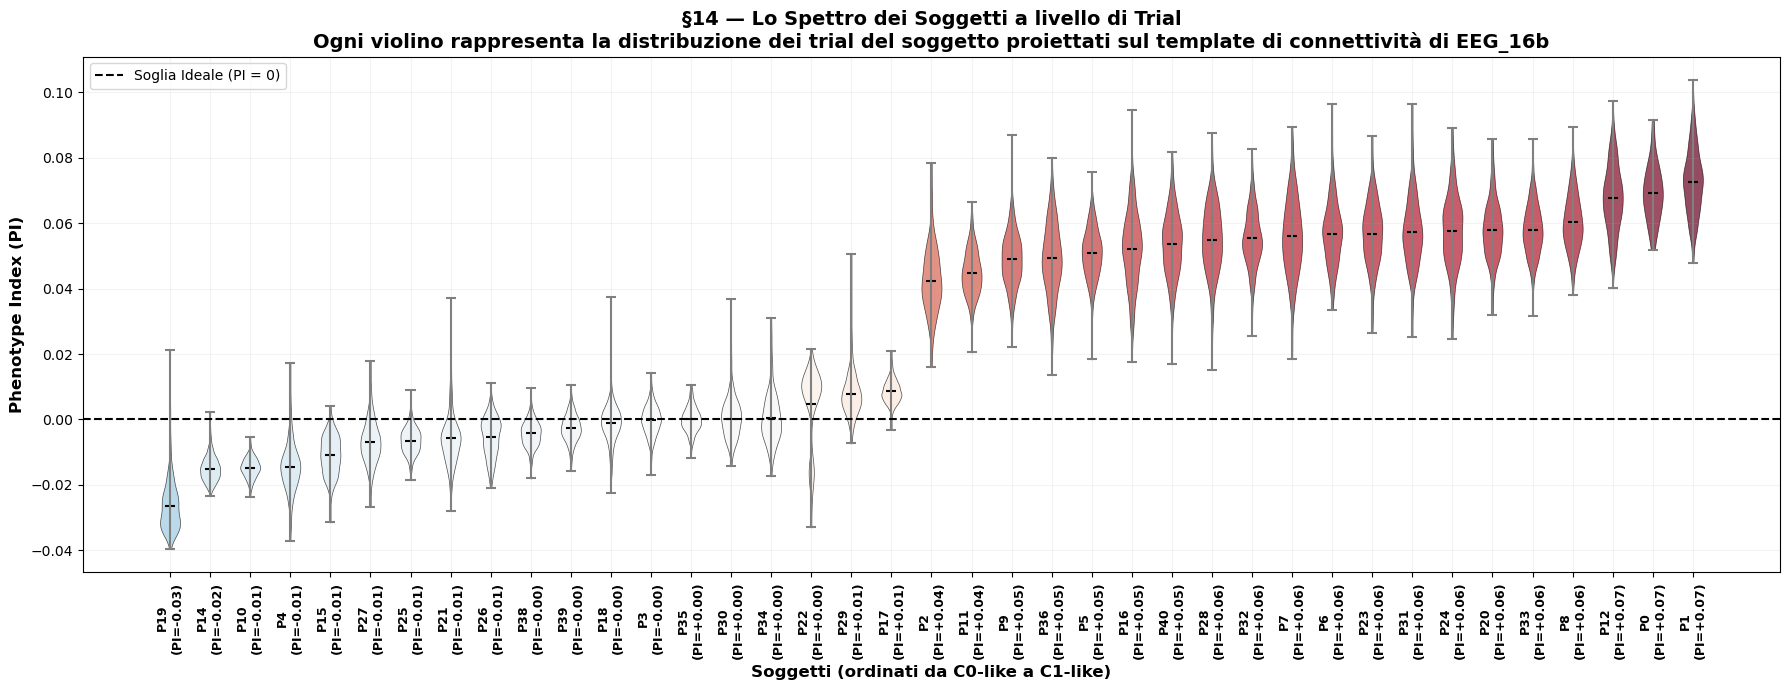

ANALISI DELLO SPETTRO (Phenotype Index):
Estremo C0 (Fronto-motor):
  P 19: PI medio = -0.026  (100% C0-like)
  P 14: PI medio = -0.015  (100% C0-like)
  P 10: PI medio = -0.015  (100% C0-like)
Zona grigia (Intermedi/Ibridi):
  P 35: PI medio = +0.000  (99.9% ibrido)
  P  3: PI medio = -0.000  (99.8% ibrido)
  P 30: PI medio = +0.000  (99.6% ibrido)
Estremo C1 (Fronto-occipital):
  P 12: PI medio = +0.068  (100% C1-like)
  P  0: PI medio = +0.069  (100% C1-like)
  P  1: PI medio = +0.073  (100% C1-like)


In [78]:
# === §14 — Calcolo del Phenotype Index (PI) e plot dello spettro ===
# diff_16b è calcolato in §4b ed è la differenza C1-C0 di EEG_16b.
# Per comodità, usiamo diff_16b come "template" di proiezione.
# Per calcolare il PI, calcoliamo la node strength del soggetto o del trial,
# e ne facciamo il prodotto scalare con diff_16b.

# Definiamo i soggetti attivi in base alla presenza di esclusioni in §3b
use_exclusion = 'LAB_K' in globals() and 'SUBJ_K' in globals()
active_subjects = SUBJ_K if use_exclusion else SUBJ
log.info(f'Calcolo Phenotype Index per {len(active_subjects)} soggetti attivi')

# 1. PI a livello di Soggetto
subj_pi = {}
for sid in active_subjects:
    # Calcola node strength per il soggetto s
    adj_s = vec_to_sym(FEAT_G[SUBJ.index(sid)])
    ns_s = adj_s.sum(1) / (N_CHAN - 1)
    # Proietta sul template diff_16b
    subj_pi[sid] = np.dot(ns_s, diff_16b)

# 2. PI a livello di Trial
trial_pi = []
for i in range(len(X_trial)):
    # Calcola node strength per il trial i
    adj_t = vec_to_sym(X_trial[i])
    ns_t = adj_t.sum(1) / (N_CHAN - 1)
    # Proietta sul template diff_16b
    t_pi = np.dot(ns_t, diff_16b)
    trial_pi.append(t_pi)
trial_pi = np.array(trial_pi)

# 3. Ordina i soggetti in base al loro PI medio (da C0 più forte a C1 più forte)
sorted_subj_ids = sorted(active_subjects, key=lambda s: subj_pi[s])

# Raggruppa i PI dei trial per ciascun soggetto
trial_pi_by_subj = {sid: [] for sid in active_subjects}
for i, sid in enumerate(TRIAL_SUBJ_V):
    if sid in trial_pi_by_subj:
        trial_pi_by_subj[sid].append(trial_pi[i])

# Prepariamo i dati per il plot a violino
plot_data = [trial_pi_by_subj[sid] for sid in sorted_subj_ids]
subj_labels = [f"P{sid}\n(PI={subj_pi[sid]:+.2f})" for sid in sorted_subj_ids]

# 4. Plot dello Spettro dei soggetti (Violin Plot)
fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Colori per i violini: gradient da blu (C0) a rosso (C1)
# Usiamo subj_pi normalizzato per mappare sui colori della colormap 'RdBu_r'
pi_vals = np.array([subj_pi[s] for s in sorted_subj_ids])
pi_min, pi_max = pi_vals.min(), pi_vals.max()
max_abs = max(abs(pi_min), abs(pi_max))
norm_pi = (pi_vals + max_abs) / (2 * max_abs) if max_abs > 0 else np.zeros_like(pi_vals) + 0.5
cmap = plt.cm.get_cmap('RdBu_r')

violins = ax.violinplot(plot_data, showmeans=True, showmedians=False, showextrema=True)

# Applica i colori sfumati ai violini
for i, pc in enumerate(violins['bodies']):
    color = cmap(norm_pi[i])
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)
    pc.set_alpha(0.7)

# Colora le linee del violino
violins['cmeans'].set_color('black')
violins['cmeans'].set_linewidth(1.5)
violins['cmins'].set_color('gray')
violins['cmaxes'].set_color('gray')
violins['cbars'].set_color('gray')

# Linea di soglia a PI=0 (separatore ideale tra C0 e C1)
ax.axhline(0, color='black', ls='--', lw=1.5, label='Soglia Ideale (PI = 0)')

# Dettagli del plot
ax.set_xticks(range(1, len(sorted_subj_ids) + 1))
ax.set_xticklabels(subj_labels, rotation=90, fontsize=9, fontweight='bold')
ax.set_ylabel('Phenotype Index (PI)', fontsize=12, fontweight='bold')
ax.set_xlabel('Soggetti (ordinati da C0-like a C1-like)', fontsize=12, fontweight='bold')
ax.set_title('§14 — Lo Spettro dei Soggetti a livello di Trial\n'
             'Ogni violino rappresenta la distribuzione dei trial del soggetto proiettati sul template di connettività di EEG_16b',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.15)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'v5w05_subject_spectrum.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Stampa i tre soggetti più rappresentativi per ogni estremo e per la zona intermedia
print('='*60)
print('ANALISI DELLO SPETTRO (Phenotype Index):')
print('='*60)
print(f'Estremo C0 (Fronto-motor):')
for sid in sorted_subj_ids[:3]:
    print(f'  P{sid:>3d}: PI medio = {subj_pi[sid]:+.3f}  (100% C0-like)')
print(f'Zona grigia (Intermedi/Ibridi):')
middle_subj_ids = sorted(active_subjects, key=lambda s: abs(subj_pi[s]))[:3]
for sid in middle_subj_ids:
    print(f'  P{sid:>3d}: PI medio = {subj_pi[sid]:+.3f}  ({(1-abs(subj_pi[sid])/max_abs)*100:.1f}% ibrido)')
print(f'Estremo C1 (Fronto-occipital):')
for sid in sorted_subj_ids[-3:]:
    print(f'  P{sid:>3d}: PI medio = {subj_pi[sid]:+.3f}  (100% C1-like)')
print('='*60)


Soggetti con trial validi: 72 su 89


/tmp/ipykernel_1009735/3158974361.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdBu_r')


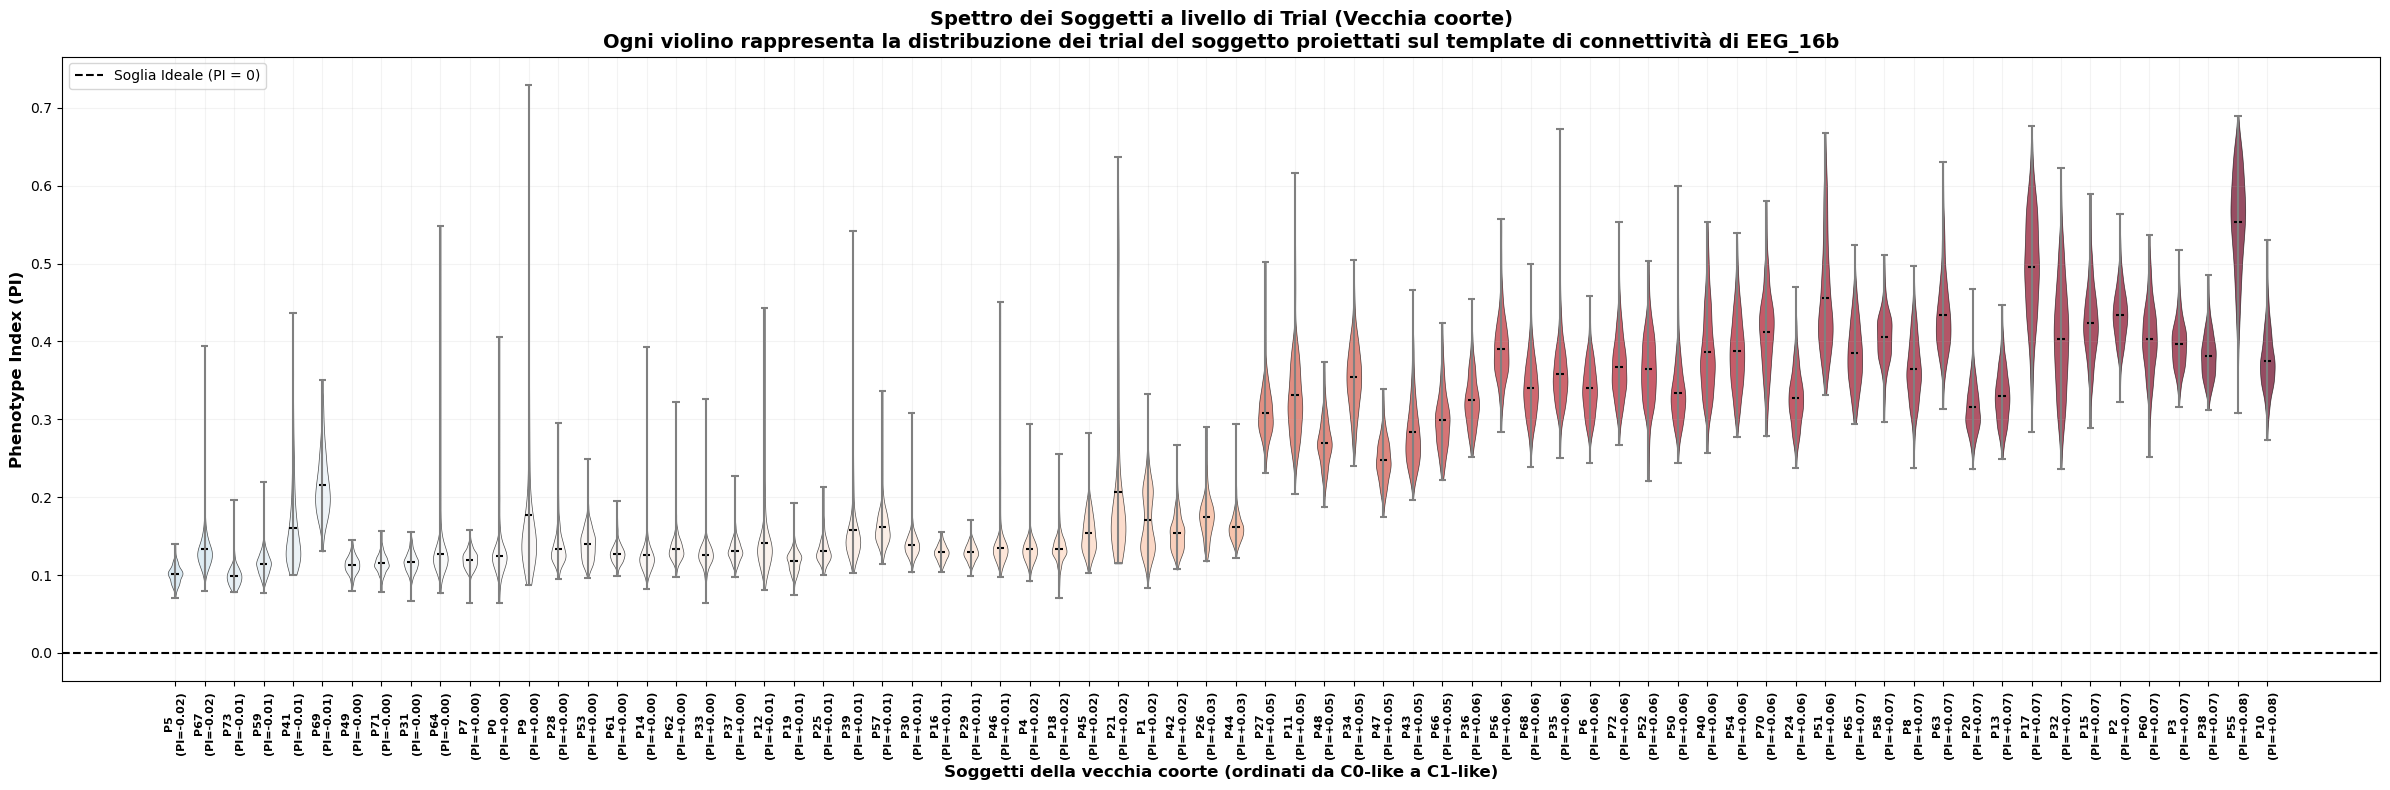

ANALISI DELLO SPETTRO (Phenotype Index - VECCHIA COORTE):
Estremo C0 (Fronto-motor):
  P  5: PI medio = -0.017
  P 67: PI medio = -0.016
  P 73: PI medio = -0.011
Zona grigia (Intermedi/Ibridi):
  P  7: PI medio = +0.000  (99.4% ibrido)
  P  0: PI medio = +0.001  (99.3% ibrido)
  P 64: PI medio = -0.001  (99.2% ibrido)
Estremo C1 (Fronto-occipital):
  P 38: PI medio = +0.074
  P 55: PI medio = +0.076
  P 10: PI medio = +0.077


In [81]:
# === §14 — Calcolo del Phenotype Index (PI) e plot dello spettro (VECCHIA COORTE) ===
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 0. Costanti e setup di base
project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'
N_CHAN = 61
RANDOM_SEED = 42
triu_idx = np.triu_indices(N_CHAN, k=1)

def vec_to_sym(v):
    M = np.zeros((N_CHAN, N_CHAN))
    M[triu_idx] = v
    return M + M.T

def cluster_k2(feat):
    X = StandardScaler().fit_transform(feat)
    Z = PCA(n_components=min(20, feat.shape[0]-1), random_state=RANDOM_SEED).fit_transform(X)
    lab = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
    return lab

# 1. Carica i dati a livello di SOGGETTO della vecchia coorte
EEG16B_CACHE = project_root / 'models' / 'eeg16b' / 'feat_graph_abs_pcc.npz'
assert EEG16B_CACHE.exists(), f"Manca la cache EEG_16b: {EEG16B_CACHE}. Assicurati che esista."
_e = np.load(EEG16B_CACHE, allow_pickle=True)
FEAT_G_16b = _e['feat']
SUBJ_16b = _e['subj_ids'].tolist()

# 2. Calcola le label di cluster a soggetto-livello per la vecchia coorte
LAB_16b = cluster_k2(FEAT_G_16b)
# Orienta in modo convenzionale: C0 più numeroso
if (LAB_16b == 1).sum() > (LAB_16b == 0).sum():
    LAB_16b = 1 - LAB_16b

# 3. Costruisci il template diff_16b (C1 - C0) per la vecchia coorte
adj0_16b = np.mean([vec_to_sym(FEAT_G_16b[i]) for i in range(len(SUBJ_16b)) if LAB_16b[i] == 0], axis=0)
adj1_16b = np.mean([vec_to_sym(FEAT_G_16b[i]) for i in range(len(SUBJ_16b)) if LAB_16b[i] == 1], axis=0)
ns0_16b = adj0_16b.sum(1) / (N_CHAN - 1)
ns1_16b = adj1_16b.sum(1) / (N_CHAN - 1)
diff_16b = ns1_16b - ns0_16b

# 4. Calcola il Phenotype Index (PI) medio a livello di soggetto per la vecchia coorte
subj_pi = {}
for sid in SUBJ_16b:
    idx = SUBJ_16b.index(sid)
    adj_s = vec_to_sym(FEAT_G_16b[idx])
    ns_s = adj_s.sum(1) / (N_CHAN - 1)
    subj_pi[sid] = np.dot(ns_s, diff_16b)

# 5. Carica i dati a livello di TRIAL della vecchia coorte
EEG19_TRIAL_CACHE = project_root / 'models' / 'eeg19' / 'feat_trial_abs_pcc.npz'
assert EEG19_TRIAL_CACHE.exists(), f"Manca la cache trial di EEG_19: {EEG19_TRIAL_CACHE}. Esegui prima EEG_19."
_t = np.load(EEG19_TRIAL_CACHE, allow_pickle=True)
FEAT_TRIAL_16b = _t['feat']
TRIAL_SUBJ_16b = _t['subj'].tolist()

# Calcola il PI per tutti i trial della vecchia coorte
trial_pi = []
for i in range(len(FEAT_TRIAL_16b)):
    adj_t = vec_to_sym(FEAT_TRIAL_16b[i])
    ns_t = adj_t.sum(1) / (N_CHAN - 1)
    t_pi = np.dot(ns_t, diff_16b)
    trial_pi.append(t_pi)
trial_pi = np.array(trial_pi)

# 6. Raggruppa i PI dei trial per ciascun soggetto
trial_pi_by_subj = {sid: [] for sid in SUBJ_16b}
for i, sid in enumerate(TRIAL_SUBJ_16b):
    if sid in trial_pi_by_subj:
        trial_pi_by_subj[sid].append(trial_pi[i])

# >>> FILTRO CRITICO: selezioniamo solo i soggetti che hanno trial validi <<<
active_subjects = [s for s in SUBJ_16b if len(trial_pi_by_subj[s]) > 0]
print(f"Soggetti con trial validi: {len(active_subjects)} su {len(SUBJ_16b)}")

# 7. Ordina i soggetti attivi in base al loro PI medio (da C0 più forte a C1 più forte)
sorted_subj_ids = sorted(active_subjects, key=lambda s: subj_pi[s])

# Prepariamo i dati per il plot a violino
plot_data = [trial_pi_by_subj[sid] for sid in sorted_subj_ids]
subj_labels = [f"P{sid}\n(PI={subj_pi[sid]:+.2f})" for sid in sorted_subj_ids]

# 8. Disegna il Violin Plot dello Spettro dei soggetti (Vecchia coorte)
fig, ax = plt.subplots(figsize=(24, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Colori per i violini: gradient da blu (C0) a rosso (C1)
pi_vals = np.array([subj_pi[s] for s in sorted_subj_ids])
pi_min, pi_max = pi_vals.min(), pi_vals.max()
max_abs = max(abs(pi_min), abs(pi_max))
norm_pi = (pi_vals + max_abs) / (2 * max_abs) if max_abs > 0 else np.zeros_like(pi_vals) + 0.5
cmap = plt.cm.get_cmap('RdBu_r')

violins = ax.violinplot(plot_data, showmeans=True, showmedians=False, showextrema=True)

# Applica i colori sfumati ai violini
for i, pc in enumerate(violins['bodies']):
    color = cmap(norm_pi[i])
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.5)
    pc.set_alpha(0.7)

# Colora le linee del violino
violins['cmeans'].set_color('black')
violins['cmeans'].set_linewidth(1.5)
violins['cmins'].set_color('gray')
violins['cmaxes'].set_color('gray')
violins['cbars'].set_color('gray')

# Linea di soglia a PI=0 (separatore ideale tra C0 e C1)
ax.axhline(0, color='black', ls='--', lw=1.5, label='Soglia Ideale (PI = 0)')

# Dettagli del plot
ax.set_xticks(range(1, len(sorted_subj_ids) + 1))
ax.set_xticklabels(subj_labels, rotation=90, fontsize=8, fontweight='bold')
ax.set_ylabel('Phenotype Index (PI)', fontsize=12, fontweight='bold')
ax.set_xlabel('Soggetti della vecchia coorte (ordinati da C0-like a C1-like)', fontsize=12, fontweight='bold')
ax.set_title('Spettro dei Soggetti a livello di Trial (Vecchia coorte)\n'
             'Ogni violino rappresenta la distribuzione dei trial del soggetto proiettati sul template di connettività di EEG_16b',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.15)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg19_subject_spectrum.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Stampa i tre soggetti più rappresentativi per ogni estremo e per la zona intermedia
print('='*60)
print('ANALISI DELLO SPETTRO (Phenotype Index - VECCHIA COORTE):')
print('='*60)
print(f'Estremo C0 (Fronto-motor):')
for sid in sorted_subj_ids[:3]:
    print(f'  P{sid:>3d}: PI medio = {subj_pi[sid]:+.3f}')
print(f'Zona grigia (Intermedi/Ibridi):')
middle_subj_ids = sorted(active_subjects, key=lambda s: abs(subj_pi[s]))[:3]
for sid in middle_subj_ids:
    print(f'  P{sid:>3d}: PI medio = {subj_pi[sid]:+.3f}  ({(1-abs(subj_pi[sid])/max_abs)*100:.1f}% ibrido)')
print(f'Estremo C1 (Fronto-occipital):')
for sid in sorted_subj_ids[-3:]:
    print(f'  P{sid:>3d}: PI medio = {subj_pi[sid]:+.3f}')
print('='*60)
